## <font color='blue'> Case German Credit Scoring </font>

### 1º Etapa: Objetivo

Este projeto está inserido na área de **Modelagem de Risco de Crédito** e utiliza um dataset com **1.000 registros**, cada um contendo **10 variáveis (features)** que descrevem características de clientes que solicitaram crédito bancário.

O objetivo principal é desenvolver um **Modelo de Classificação Preditivo** capaz de identificar se um cliente representa **Baixo ou Alto Risco de Crédito**.

A variável alvo do modelo é **Risco**, que classifica os clientes em:

- **Good** → bons pagadores (baixo risco)
- **Bad** → maus pagadores (alto risco)

O modelo busca prever essa classificação com base nas características dos clientes, auxiliando processos de **Concessão, Monitoramento e Gestão de Crédito** em instituições financeiras.

##### Dicionário de Dados:

Base Original:
| Variável | Tipo | Descrição |
|--------|------|-----------|
| Age | Numérica | Idade do cliente em anos |
| Sex | Categórica | Gênero do cliente |
| Job | Categórica ordinal | Nível de qualificação profissional |
| Housing | Categórica | Tipo de moradia do cliente |
| Saving accounts | Categórica | Situação da conta poupança |
| Checking account | Categórica | Situação da conta corrente |
| Credit amount | Numérica | Valor do crédito solicitado |
| Duration | Numérica | Duração do empréstimo em meses |
| Purpose | Categórica | Finalidade do crédito |
| Risk | Categórica (target) | Classificação de risco do cliente |

Base após Transformação dos Dados:
| Variável | Tipo | Descrição |
|--------|------|-----------|
| Genero | Binária | Gênero do cliente (1 = masculino, 0 = feminino) |
| Trabalho | Ordinal | Nível de qualificação profissional do cliente (0 = desempregado / não qualificado, 1 = não qualificado residente, 2 = qualificado, 3 = altamente qualificado / gestor) |
| Faixa_Etaria | Ordinal | Faixa de idade do cliente categorizada em intervalos |
| Conta_poupança | Ordinal | Nível de recursos na conta poupança (little = baixo, moderate = médio, rich = alto) |
| Conta_corrente | Ordinal | Nível de recursos na conta corrente (little = baixo, moderate = médio, rich = alto) |
| Faixa_Duracao | Ordinal | Intervalos da duração do empréstimo em meses |
| Faixa_Credito | Ordinal | Intervalos do valor de crédito solicitado |
| Habitação_own | Binária | Indica se o cliente possui casa própria (1 = sim, 0 = não) |
| Habitação_rent | Binária | Indica se o cliente mora de aluguel (1 = sim, 0 = não) |
| Finalidade_* | Binária | Variáveis dummy que representam a finalidade do crédito (1 = pertence à categoria, 0 = não pertence) |
| Risco | Binária (Target) | Variável alvo do modelo (1 = bom pagador, 0 = mau pagador) |

### Estrutura do Projeto

1º Etapa - Compreensão dos Dados (Objetivo, Dicionário, Estrutura) <br>
2º Etapa - Importação de Bibliotecas <br>
3º Etapa - Carregamento do Conjunto de Dados <br>
4º Etapa - Análise Descritiva dos Dados <br>
5º Etapa - Análise Exploratória (EDA) <br>
6º Etapa - Insights Extraídos da Análise Exploratória <br>
7º Etapa - Feature engineering <br>
8️º Etapa - Feature Selection com WOE e Information Value (IV) <br>
9º Etapa - Pré-Processamento dos Dados <br>
10º Etapa - Análise de Correlação e Multicolinearidade <br>
11º Etapa - Modelagem dos Dados (Modelo Baseline) <br>
12º Etapa - Avaliação do Modelo (AUC, GINI, KS) <br>
13º Etapa - Relatório de Avaliação do Modelo Baseline <br>
14º Etapa - Otimização do Modelo <br>
15º Etapa - Scoring Crédito <br>
16º Etapa - Conclusão Final do Projeto <br>

### 2º Etapa: Importação de Bibliotecas

In [673]:
# ==================================================
# 1. MANIPULAÇÃO DE DADOS
# ==================================================
import pandas as pd
import numpy as np

# ==================================================
# 2. VISUALIZAÇÃO DE DADOS
# ==================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

# ==================================================
# 3. ANÁLISE EXPLORATÓRIA
# ==================================================
from summarytools import dfSummary

# ==================================================
# 4. PRÉ-PROCESSAMENTO
# ==================================================
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ==================================================
# 5. BALANCEAMENTO (BASELINE)
# ==================================================
from imblearn.over_sampling import SMOTE

# ==================================================
# 6. DIVISÃO DE DADOS
# ==================================================
from sklearn.model_selection import train_test_split

# ==================================================
# 7. MODELOS
# ==================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==================================================
# 8. MÉTRICAS
# ==================================================
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

# ==================================================
# 9. UTILITÁRIOS
# ==================================================
import pickle
import warnings

# ==================================================
# 10. CONFIGURAÇÕES
# ==================================================
warnings.filterwarnings('ignore')

# Configuração do pandas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)

# Configuração de gráficos
plt.rcParams['figure.figsize'] = (15,6)
plt.style.use('classic')

# ==================================================
# 11. CONTROLE DE VERSÕES (OPCIONAL)
# ==================================================
%reload_ext watermark
%watermark -a "Versões Utilizadas" --iversions

Author: Versões Utilizadas

json        : 2.0.9
missingno   : 0.5.2
summarytools: 0.2.3
joblib      : 1.4.2
seaborn     : 0.13.2
matplotlib  : 3.10.1
scorecardpy : 0.1.9.7
optuna      : 4.8.0
xgboost     : 3.2.0
imblearn    : 0.14.1
numpy       : 2.2.4
plotly      : 6.0.1
statsmodels : 0.14.6
sklearn     : 1.6.1
pandas      : 2.2.3



### 3º Etapa: Carregamento do Conjunto de Dados

In [555]:
# Carregar os dados
df = pd.read_csv('C:/Users/Fernanda Pavan/OneDrive/Desktop/Projeto_Fer/dataset/Dados_German_Credit/german_credit_data.csv')

In [556]:
# Visualizar o conjunto de dados - as primeiras Linhas
df.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [557]:
# Visualizar as últimas linhas - conferir se bate o com o valor da dimensão
df.tail(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,999,27,male,2,own,moderate,moderate,4576,45,car,good


In [558]:
# verificar a Dimensão da base
df.shape

(1000, 11)

### 4º Etapa: Análise Descritiva dos Dados

##### 1. Análise Descritiva dos Dados

In [559]:
# Verificar o resumo das informações (qual o tipo de cada variável)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [560]:
# Verificar a distribuição de frequência da variável Target
df.Risk.value_counts(normalize = True)

Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

In [561]:
# verificar valores faltantes
(df.isna().sum()/df.shape[0] * 100).round(2).sort_values()

Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Credit amount        0.0
Purpose              0.0
Duration             0.0
Risk                 0.0
Saving accounts     18.3
Checking account    39.4
dtype: float64

In [562]:
# Porcentagem Total de valores nulos do conjunto de dados
total_linhas = df.shape[0]
missing = df.isnull().sum().sum()
total_nulos = ((missing / total_linhas) * 100).round(2).item()
total_nulos

57.7

In [563]:
# Verificar a quantidade de valores Nulos (missing)
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [564]:
# Porcentagem de valores nulos por coluna
porcentagem_coluna = df.isnull().sum() / len(df) * 100
porcentagem_coluna

Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64

<Axes: >

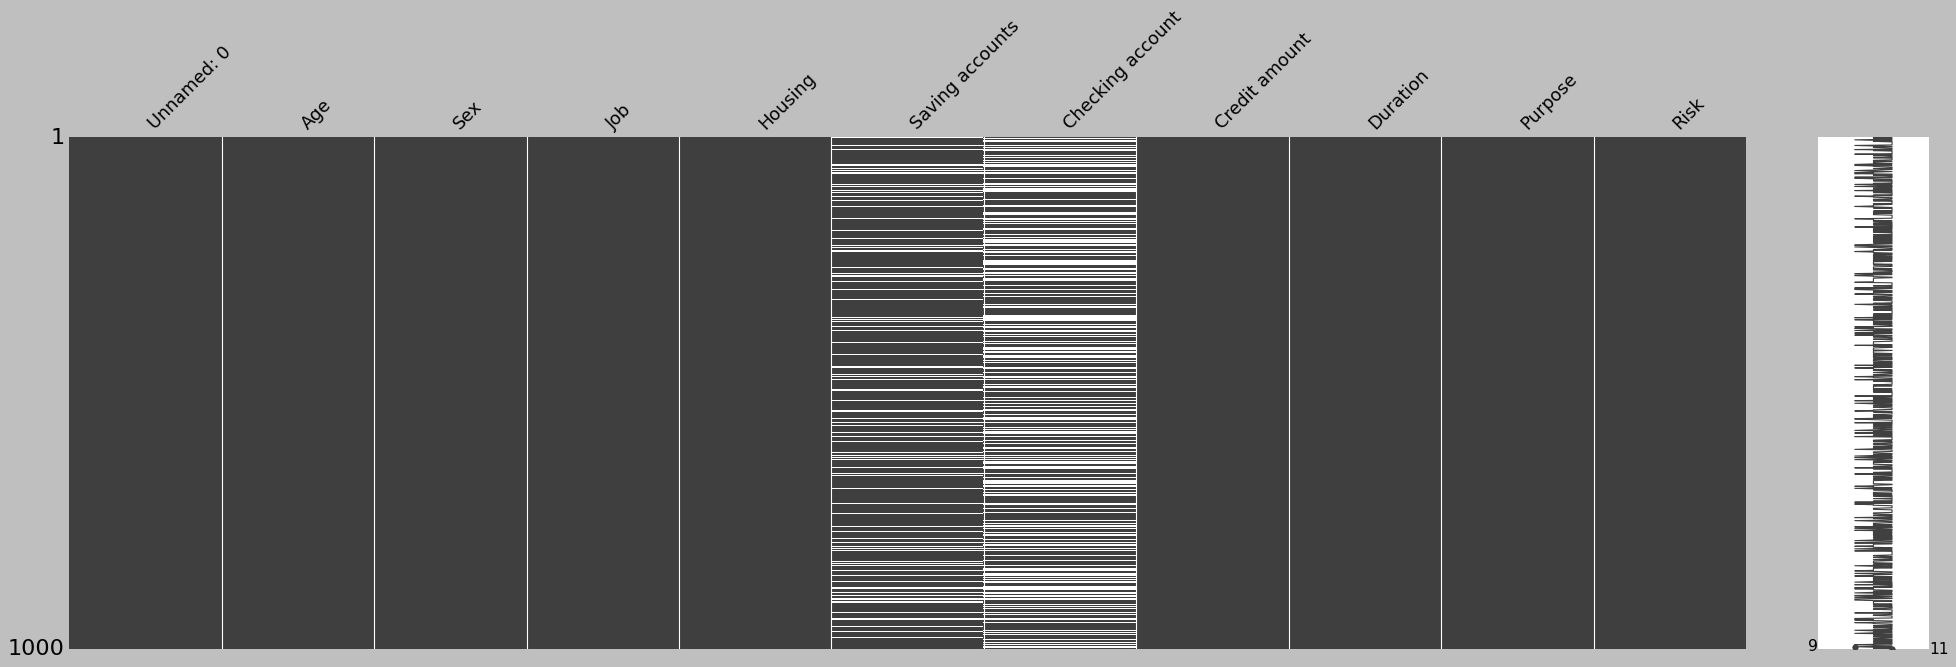

In [565]:
# Visualização Gráfica da quantidade de dados faltantes
# Maneira mais visual de verificar valores nulos nas diferentes variáveis do dataframe
missingno.matrix(df, figsize=(30,8))

In [566]:
# verificar se há valores duplicados na base
df[df.duplicated()]

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk


In [567]:
# linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [568]:
# coluna constante
df.columns[df.nunique() == 1]

Index([], dtype='object')

In [569]:
# verificar os valores únicos de cada variável
df.nunique().sort_values()

Sex                    2
Risk                   2
Checking account       3
Housing                3
Saving accounts        4
Job                    4
Purpose                8
Duration              33
Age                   53
Credit amount        921
Unnamed: 0          1000
dtype: int64

In [570]:
# Sumário de todas as variáveis
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,Unnamed: 0[int64],Mean (sd) : 499.5 (288.8)min < med < max:0.0 < 499.5 < 999.0IQR (CV) : 499.5 (1.7),"1,000 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKQAAABACAYAAACUYNzVAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAWBJREFUeJzt0rFqwlAYhuE0WLA1KCKNF9A7cMyN9MYdunRycwkB0xaKUGIHuyqCH+F5huQs5+c/8D6sVqu3+Xy+LK5wPB4f+75/rarqoyzLn3vMGMMO3nA2GWJsmuZrsVh8Fxfa7XbL7Xb7stls3tfrdXvp/VvMGMMO3vCn67rpZDgMMdZ1/VlcqG3bp+E/m82uun+LGWPYwRvOyn9nuDtBEkWQRBEkUQRJFEESRZBEESRRBEkUQRJFkEQRJFEESRRBEkWQRBEkUQRJFEESRZBEESRRBEkUQRJFkEQRJFEESRRBEkWQRBEkUQRJFEESRZBEESRRBEkUQRJFkEQRJFEESRRBEkWQRBEkUQRJFEESRZBEESRRBEkUQRJFkEQRJFEESRRBEkWQRBEkUQRJFEESRZBEESRRBEkUQRJFkEQRJFEmw6fruuk1lw+Hw+le3/fT/X7/fI8ZY9jBG4qTocNfPGwaMuvmV00AAAAASUVORK5CYII="">",0(0.0%)
2,Age[int64],Mean (sd) : 35.5 (11.4)min < med < max:19.0 < 33.0 < 75.0IQR (CV) : 15.0 (3.1),53 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKQAAABACAYAAACUYNzVAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAklJREFUeJzt28GK2kAcx/GZZrekSiPiojdfYGEPHn2IPmwfoYJP4Bt4ESEExXRDYkwZodBjJpD0l+T7OTussN/N5L/M2KqqDKDiy//+AsC/CBJSCBJSCBJSCBJSCBJSXowIa+03Y8xXz2V5VVWfLX0ljDVIF+NisfgRRdHcZ931ek2stT+JcjgkgnRPRhfjdrv9nM1mWZ0Fl8sl3O/38ziO3VOVIAdCJcgnF+NyufztscRt8xgQhhpIIUhIIUhIIUhIIUhIIUhIIUhIIUhIIUhIIUhIIUhIIUhIIUhIIUhIkTp+5qssy1djTGSt9VnGKXNhvQ0yTdPXoig+1ut1EARBrUO9DqfMtfU2yDzPX8IwnGw2m2y1WiV11nDKXF9vg/xrOp1yynxAGGogpfdPyI4GIYdhqK9BNrhjHT0eDxeK5CDkMAz1NMgmd6yLogjLsnzPsuyXMcbnfbD1QchhGOr3E9L7jvXxeJwfDofJ/X4PjOYg5DAM9fkd0ueOdZIk/LLxxJQNKQQJKQQJKQQJKQQJKQQJKQQJKQQJKQQJKaM77dMU1yW6QZA1cF2iOwRZA9clukOQHrgu0T6CbBHvnf4IsiW8dzZDkC3hvbMZgmwZ751++Mc4pBAkpLBliylHPpkTpJCUyZwgleRM5gQ5hMm8LMtoKNs8QfZcOrBtniBHus3vdrtlHMdv1tqrz49rO2CCHOE2nwo/VQlyhHLh4YkgR2wqODy1FqT7i6r72dvt9vxsmqbh+XyeKK1R/363jtacTqfvXWzzfwDQ9bqKuoLaWAAAAABJRU5ErkJggg=="">",0(0.0%)
3,Sex[object],1. male2. female,690 (69.0%)310 (31.0%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAwCAYAAAAGugihAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAT5JREFUeJzt3DFqwzAUh/GnYkq62ASBD+NDZO09ewjfRgRraEoWlQdZQ6HD33nW9xu8WpBvsIL0Us75cxzHs+Hl1VqvpZSv1trNAho8tGVZbtM0/ey9GDy3bdtpXddzKeXdzGLG5g8PbZ7n770Xgz99WGBvey8A/SA2yBAbZIgNMsQGGWKDDLFBhtggQ2yQITbIEBtkiA0yxAYZYoMMsUGG2CBDbNCe1PUjx7pX4j+O8BsNfonCz7ZHP3Lcg1rr1czuFlR6ROaXKPD67lFvVrnUWtt7DegEGwTIEBtkjvDNFvo7pidDzvkSefyC79BSSmFHEvQk9PiFI4wk6MkRxi/w/2AQbBAgQ2yQITbIEBtkiA0yxAYZYoMMsUGG2CBDbJAhNsgQG2SIDTLEBhligwyxQYbYIBN6/ELUdVunfgGVzVXH43BKVwAAAABJRU5ErkJggg=="">",0(0.0%)
4,Job[int64],1. 22. 13. 34. 0,630 (63.0%)200 (20.0%)148 (14.8%)22 (2.2%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABgCAYAAAAKNABWAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAepJREFUeJzt3U1K5EAAhuGKNDKz6UYCfZg+xGznnh6ibxOks9DBTYaC9gf3ftVWPQ8ouDLIC0lJPp3mef673+8fCk2t6/q0LMvjtm0vpVO7GtrpdHo5HA7/Wl/MqC6Xy6/z+fywLMt9KaXf2OqnGtrxeHxufTGD+106d9f6AhiH2IgRGzFiI0ZsxIiNGLERIzZixEaM2IgRGzFiI0ZsxIiNGLERIzayL0/WN0Vz35KvRvn57+q77/WV5BHeFL1l67o+lVJeS8ema2T13Xfaeu157FJN27a1vgYG4YDAMLfR7m8dfNjN8/yn1Ui5PhRP09T1MJcbGCmPMszldkbKft0yEAcEYsRGjNiIERsxYiNGbMSIjRixESM2YsRGjNiIERsxYiNGbMSIjRix0f9IeZRhLjcyUh5hmMsH6ypijJSJcUAgRmx088zmmYzMIt7incgi3uKd9CLe4p13DgjEiI0YsREjNmLERozYiBEbMWIjRmzEiI0YsREjNmLERozYiBEbMWLj5y/iLd6JLuIt3vnMuooYi3hiHBBodht12yMzUjYq5jvdvY2U68c1ulZ/PotRRsrXr42K+TYOCMSIjRixESM2YsRGjNiIERsxYiNGbMSIjRixESM2YsRGjNiIERsxYqP/f9tNGc5/RgG0U2lnbT8AAAAASUVORK5CYII="">",0(0.0%)
5,Housing[object],1. own2. rent3. free,713 (71.3%)179 (17.9%)108 (10.8%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABHCAYAAAAQnTXYAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjEsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvc2/+5QA

In [571]:
# Verificar resumo estatístico das colunas numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,499.500,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,35.546,11.375469,19.0,27.00,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.00,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.50,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.00,18.0,24.00,72.0


In [572]:
# Verificar resumo estatístico das colunas categóricas
df.describe(include=object)

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


##### 2. Identificação de Problemas no Dataset:

1. Remover variáveis que não serão utilizadas (Unnamed: 0)
2. Variáveis com dados faltantes: (Saving accounts, Checking account)
3. Renomear variáveis de inglês para português
4. Agrupamento em Classes (Binning/Discretização) para as variáveis (Age, Credit amount, Duration).

##### 3. Tratamento dos Dados

In [573]:
# 1) Criar novo Dataset para Realizar as Transformações
df1 = df.copy()

In [574]:
# 2) Substituir os valores nulos por zero(0)
df1['Saving accounts'].fillna(0, inplace=True)
df1['Checking account'].fillna(0, inplace=True)

In [575]:
# 3) Colocar os valores Zeros dentro da categoria "little"
df1['Saving accounts'] = df1['Saving accounts'].replace(0,'little')
df1['Checking account'] = df1['Checking account'].replace(0,'little')

In [576]:
# 4) Unir a Categoria "quiche rich" na categoria "rich"
df1['Saving accounts'] = df1['Saving accounts'].replace('quite rich', 'rich')

In [577]:
# 5) Conferir as colunas que estavam com valores nulos
df1.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [578]:
# 6) Renomear as Variáveis
df1.rename(columns={
    'Unnamed: 0': 'Unnamed: 0',
    'Age': 'Idade',
    'Sex': 'Genero',
    'Job': 'Trabalho',
    'Housing': 'Habitação',
    'Saving accounts': 'Conta_poupança',
    'Checking account': 'Conta_corrente',
    'Credit amount': 'Valor_credito',
    'Duration': 'Duracao',
    'Purpose': 'Finalidade',
    'Risk': 'Risco'
}, inplace=True)

df1

,Unnamed: 0,Idade,Genero,Trabalho,Habitação,Conta_poupança,Conta_corrente,Valor_credito,Duracao,Finalidade,Risco
0,0,67,male,2,own,little,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,little,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,little,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,little,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [579]:
# 7) Transformar a variável Idade em Faixa_Etaria

idade_bins = [0, 28, 38, 48, 58, 68, 78]
idade_categoria = ['19-28', '29-38', '39-48', '49-58', '59-68', '69-78']

# Contagem e Ordenação pela ORDEM DAS CATEGORIAS (ÍNDICE)
df1["Faixa_Etaria"] = pd.cut(
    df1["Idade"], 
    bins=idade_bins, 
    labels=idade_categoria,
)

faixa_etaria_ordenada = df1["Faixa_Etaria"].value_counts().sort_index(ascending=True)

print("Contagem por Faixa Etária:\n\n", faixa_etaria_ordenada)

Contagem por Faixa Etária:

 Faixa_Etaria
19-28    334
29-38    346
39-48    181
49-58     85
59-68     47
69-78      7
Name: count, dtype: int64


In [580]:
# 8) Transformar a variável Duração em faixa_duração com intervalos de 12 meses

duracao_bins = [0, 15, 27, 39, 51, 63, 75]
duracao_categoria = ['4-15', '16-27', '28-39','40-51', '52-63', '64-75']

# Criar nova coluna 
df1['Faixa_Duracao'] = pd.cut(df1['Duracao'], bins= duracao_bins, labels= duracao_categoria,)

# Quantidade por faixa de Duração
quantidade_duracao = df1['Faixa_Duracao'].value_counts().sort_index()

print('Quantidade por Faixa de Duração:\n\n', quantidade_duracao)

Quantidade por Faixa de Duração:

 Faixa_Duracao
4-15     431
16-27    353
28-39    134
40-51     66
52-63     15
64-75      1
Name: count, dtype: int64


In [581]:
# 9) Transformar a variável Valor_Credito em Faixa_credito

# 1. Definir os intervalos (bins) de 1000 em 1000 conforme o Excel
credito_bins = [250, 1250, 2250, 3250, 4250, 5250, 6250, 7250, 8250, 9250, 
                10250, 11250, 12250, 13250, 14250, 15250, 16250, 17250, 18250, 19250]

# 2. Definir as etiquetas (labels) para cada faixa
credito_categoria = ['250-1249', '1250-2249', '2250-3249', '3250-4249', '4250-5249', 
                     '5250-6249', '6250-7249', '7250-8249', '8250-9249', '9250-10249', 
                     '10250-11249', '11250-12249', '12250-13249', '13250-14249', 
                     '14250-15249', '15250-16249', '16250-17249', '17250-18249', '18250-19249']

# 3. Criar a nova coluna Faixa_Credito
# right=False garante que o limite superior não entre na faixa atual (ex: 1250 vai para a próxima)
df1['Faixa_Credito'] = pd.cut(df1['Valor_credito'], bins=credito_bins, labels=credito_categoria, right=False)

# 4. Quantidade por faixa de Crédito
quantidade_credito = df1['Faixa_Credito'].value_counts().sort_index()

print('Quantidade por Faixa de Crédito:\n\n', quantidade_credito)

Quantidade por Faixa de Crédito:

 Faixa_Credito
250-1249       194
1250-2249      292
2250-3249      172
3250-4249      112
4250-5249       55
5250-6249       36
6250-7249       41
7250-8249       33
8250-9249       15
9250-10249      13
10250-11249      9
11250-12249      9
12250-13249      6
13250-14249      3
14250-15249      5
15250-16249      4
16250-17249      0
17250-18249      0
18250-19249      1
Name: count, dtype: int64


In [582]:
df1.head()

,Unnamed: 0,Idade,Genero,Trabalho,Habitação,Conta_poupança,Conta_corrente,Valor_credito,Duracao,Finalidade,Risco,Faixa_Etaria,Faixa_Duracao,Faixa_Credito
0,0,67,male,2,own,little,little,1169,6,radio/TV,good,59-68,4-15,250-1249
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,19-28,40-51,5250-6249
2,2,49,male,1,own,little,little,2096,12,education,good,49-58,4-15,1250-2249
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good,39-48,40-51,7250-8249
4,4,53,male,2,free,little,little,4870,24,car,bad,49-58,16-27,4250-5249


### 5º Etapa: Análise Exploratória (EDA)

##### 1. Vamos Analisar a Taxa Geral de Risco do Dataframe

In [583]:
# Calcula a porcentagem de cada categoria de Risco no total do DataFrame
taxa_risco_geral = df1["Risco"].value_counts(normalize=True).round(3) * 100

print("Taxa Geral de Risco (Total do DataFrame):\n")
print(taxa_risco_geral)

Taxa Geral de Risco (Total do DataFrame):

Risco
good    70.0
bad     30.0
Name: proportion, dtype: float64


2. Vamos Verificar quais Variáveis Ultrapassaram a Taxa Geral de Risco "Bad"

##### Variável Gênero:

1) Frequência Relativa %

In [584]:
# Porcentagem Relativa %
percentual_genero = df1["Genero"].value_counts(normalize=True).round(3)*100

print("Porcentagem Relativa % Geral do Genero:\n\n", percentual_genero)

Porcentagem Relativa % Geral do Genero:

 Genero
male      69.0
female    31.0
Name: proportion, dtype: float64


2) Taxa de Risco de Gênero

In [585]:
# Calculo para Taxa de Risco da Categoria gênero
taxa_risco_genero = df1.groupby(['Genero'])['Risco'].value_counts(normalize=True).round(3) * 100

print("Taxa de Risco da Categoria Gênero:\n\n",taxa_risco_genero)

Taxa de Risco da Categoria Gênero:

 Genero  Risco
female  good     64.8
        bad      35.2
male    good     72.3
        bad      27.7
Name: proportion, dtype: float64


3) Taxa de Risco Bad

In [586]:
# Filtrar somente a Taxa de Risco "BAD" 
# Usando .xs() para selecionar o valor 'bad' no nível 'Risco'

taxa_genero_bad = df1.groupby(["Genero"])["Risco"].value_counts(normalize=True).xs("bad", level="Risco").round(3) * 100

print('Taxa de Risco "BAD" por Genero:\n\n', taxa_genero_bad)

Taxa de Risco "BAD" por Genero:

 Genero
female    35.2
male      27.7
Name: proportion, dtype: float64


4) Converter em Dataframe

In [587]:
# Converter em um Dataframe para plotagem
# Conversão: Usando .reset_index()
df_taxa_genero_bad = taxa_genero_bad.reset_index()

# Renomear o Dataframe
df_taxa_genero_bad.columns = ['Genero', "Taxa_Bad_%"]

print(df_taxa_genero_bad)

   Genero  Taxa_Bad_%
0  female        35.2
1    male        27.7


5) Visualização Gráfica da Taxa de Gênero

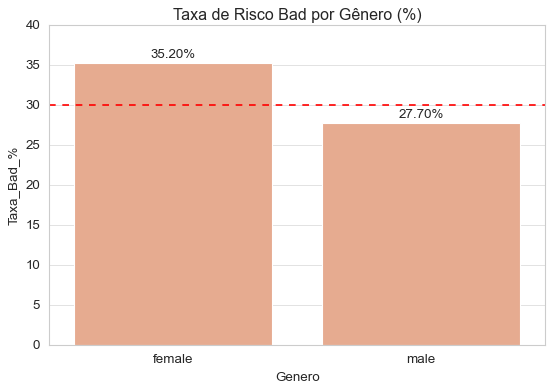

In [588]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

cor_laranja_claro = '#F4A582' 
taxa_referencia = 30

# Cria o gráfico de barras agrupadas e ARMAZENA na variável 'ax'
ax = sns.barplot(
    x='Genero',
    y='Taxa_Bad_%',
    data=df_taxa_genero_bad,
    color= '#F4A582'
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
    # Não precisa mais do 'label' aqui, pois o texto será direto
)

# NOVO CÓDIGO: Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

# Adiciona título e rótulos
plt.title('Taxa de Risco Bad por Gênero (%)')

plt.show()

O grupo feminino superou o limite de risco com 35,20%, excedendo em 5,2 p.p. a meta de 30%.<br> Enquanto o grupo masculino está dentro do esperado, o perfil feminino é o ponto de atenção para ser analisado.

##### Variável Habitação:

1) Frequência Relativa %

In [589]:
# Porcentagem Relativa % 
percentual_habitacao = df1["Habitação"].value_counts(normalize=True).round(3)*100

print("Porcentagem Relativa % \n\n", percentual_habitacao)

Porcentagem Relativa % 

 Habitação
own     71.3
rent    17.9
free    10.8
Name: proportion, dtype: float64


2) Frequência Acumulada %

In [590]:
freq_acum_habitacao = df1["Habitação"].value_counts(normalize=True).cumsum().round(3)*100

print("Frequência Acumulada de Habitação:\n\n", freq_acum_habitacao)

Frequência Acumulada de Habitação:

 Habitação
own      71.3
rent     89.2
free    100.0
Name: proportion, dtype: float64


3) Taxa de Risco de Habitação

In [591]:
# Calculo da Taxa de Risco por categoria Habitação
taxa_risco_habitacao = df1.groupby("Habitação")["Risco"].value_counts(normalize=True).round(3)*100

print("Taxa de Risco por Categoria de Habitação:\n\n", taxa_risco_habitacao)

Taxa de Risco por Categoria de Habitação:

 Habitação  Risco
free       good     59.3
           bad      40.7
own        good     73.9
           bad      26.1
rent       good     60.9
           bad      39.1
Name: proportion, dtype: float64


4) Taxa de Risco Bad

In [592]:
# Filtrar somente as Taxas Bad
taxa_bad_habitacao = df1.groupby(["Habitação"])["Risco"].value_counts(normalize=True).xs("bad", level="Risco").sort_values(ascending=False).round(3) * 100

print("Taxa de Risco Bad:\n\n",taxa_bad_habitacao )

Taxa de Risco Bad:

 Habitação
free    40.7
rent    39.1
own     26.1
Name: proportion, dtype: float64


5) Converter em Dataframe

In [593]:
# Converter em dataframe
df_taxa_bad_habitacao = taxa_bad_habitacao.reset_index()

# Renomear as Colunas
df_taxa_bad_habitacao.columns = ["Habitação", "Taxa_Bad_%"]

print("Dataframe com valores da Taxa de Risco Bad:\n\n", df_taxa_bad_habitacao)

Dataframe com valores da Taxa de Risco Bad:

   Habitação  Taxa_Bad_%
0      free        40.7
1      rent        39.1
2       own        26.1


6) Visualização Gráfica da Taxa de Risco Bad por Categoria de Habitação

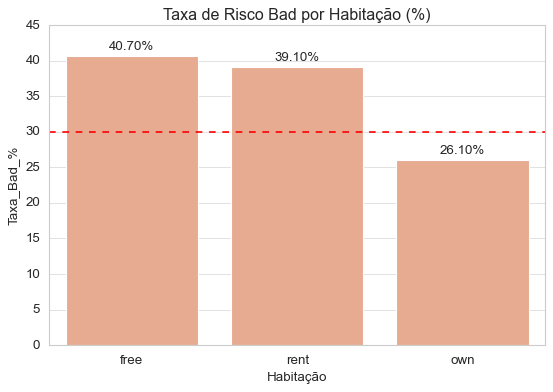

In [594]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

#cor_laranja_claro = '#F4A582' 
taxa_referencia = 30


# Cria o gráfico de barras agrupadas e ARMAZENA na variável 'ax'
ax = sns.barplot(
    x='Habitação',
    y='Taxa_Bad_%',
    data=df_taxa_bad_habitacao,
    color= '#F4A582'
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
    # Não precisa mais do 'label' aqui, pois o texto será direto
)

# NOVO CÓDIGO: Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

# Adiciona título e rótulos
plt.title('Taxa de Risco Bad por Habitação (%)')

plt.show()

Clientes em moradias (free) ou alugadas (rent) operam com risco crítico, atingindo 40,70% e 39,10%.<br> O perfil com imóvel próprio (own) é o único dentro da meta, com 26,10%.

##### Variável Conta_poupança:

1) Frequência Relativa %

In [595]:
# Porcentagem Relativa %
percentual_poupanca = df1["Conta_poupança"].value_counts(normalize=True).round(3)*100

print("Porcentagem Relativa % da Conta Poupança:\n\n",percentual_poupanca )

Porcentagem Relativa % da Conta Poupança:

 Conta_poupança
little      78.6
rich        11.1
moderate    10.3
Name: proportion, dtype: float64


In [596]:
# # Distribuição (Quantidade)
print("\nDistribuição da Conta_poupança (0=little, 1=moderate, 2=rich):")
print(df1['Conta_poupança'].value_counts().sort_index())


Distribuição da Conta_poupança (0=little, 1=moderate, 2=rich):
Conta_poupança
little      786
moderate    103
rich        111
Name: count, dtype: int64


2) Frequência Acumulada %

In [597]:
freq_acum_poupanca = df1["Conta_poupança"].value_counts(normalize=True).cumsum().round(3)*100

print("Frequência Acumulada % da Conta Poupança:\n\n",freq_acum_poupanca )

Frequência Acumulada % da Conta Poupança:

 Conta_poupança
little       78.6
rich         89.7
moderate    100.0
Name: proportion, dtype: float64


3) Taxa de Risco de Risco por Categoria da Conta Poupança

In [598]:
# Taxa de Risco por Nível da COnta Poupança
taxa_risco_poupanca = df1.groupby(["Conta_poupança"])["Risco"].value_counts(normalize=True).round(3)*100

print("Taxa de Risco por Nível da Conta Poupança:\n\n", taxa_risco_poupanca)

Taxa de Risco por Nível da Conta Poupança:

 Conta_poupança  Risco
little          good     68.3
                bad      31.7
moderate        good     67.0
                bad      33.0
rich            good     84.7
                bad      15.3
Name: proportion, dtype: float64


4) Taxa de Risco Bad

In [599]:
# Filtrar somente a Taxa Bad
taxa_bad_poupanca = df1.groupby(["Conta_poupança"])["Risco"].value_counts(normalize=True).xs("bad", level="Risco").sort_values(ascending=False).round(3)*100

print("Taxa de Risco Bad da Conta Poupança:\n\n", taxa_bad_poupanca)

Taxa de Risco Bad da Conta Poupança:

 Conta_poupança
moderate    33.0
little      31.7
rich        15.3
Name: proportion, dtype: float64


5) Converter em Dataframe

In [600]:
# Converter em dataframe 
df_taxa_bad_poupanca = taxa_bad_poupanca.reset_index()

#Renomear as Colunas
df_taxa_bad_poupanca.columns = ['Conta_Poupança', 'Taxa_Bad_%']

print("Dataframe da Taxa Bad da Poupança:\n\n", df_taxa_bad_poupanca)

Dataframe da Taxa Bad da Poupança:

   Conta_Poupança  Taxa_Bad_%
0       moderate        33.0
1         little        31.7
2           rich        15.3


6) Visualização Gráfica da Taxa Bad da Conta Poupança

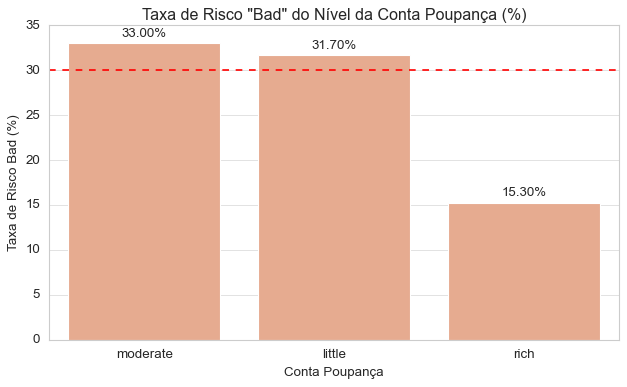

In [601]:
# --- DEFINIÇÕES ---
cor_laranja_claro = '#F4A582' 
taxa_referencia = 30 # Valor da linha de referência (30%)
# -----------------------------

# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

# Cria o gráfico de barras
ax = sns.barplot(
    x='Conta_Poupança',
    y='Taxa_Bad_%',
    data=df_taxa_bad_poupanca,
    color=cor_laranja_claro
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
)

# Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

# Adiciona título e rótulos
plt.title('Taxa de Risco "Bad" do Nível da Conta Poupança (%)')
plt.xlabel('Conta Poupança')
plt.ylabel('Taxa de Risco Bad (%)')

# Ajusta o layout para evitar cortes
plt.tight_layout() 
plt.show()

As categorias Little e Moderate superaram o limite de risco com (33% e 31,7%).

##### Variável Conta_corrente:

1) Frequência Relativa %

In [602]:
# Porcentagem Relativa %
percentual_corrente = df1["Conta_corrente"].value_counts(normalize=True).round(3)*100

print("Porcentagem Relativa % da Conta Corrente:\n\n", percentual_corrente)

Porcentagem Relativa % da Conta Corrente:

 Conta_corrente
little      66.8
moderate    26.9
rich         6.3
Name: proportion, dtype: float64


In [603]:
# Distribuição (Quantidade)
print("\nDistribuição da Conta_corrente (0=little, 1=moderate, 2=rich):")
print(df1['Conta_corrente'].value_counts().sort_index())


Distribuição da Conta_corrente (0=little, 1=moderate, 2=rich):
Conta_corrente
little      668
moderate    269
rich         63
Name: count, dtype: int64


2) Frequência Acumulada %

In [604]:
# Frequencia Acumulada %
freq_acum_corrente = df1["Conta_corrente"].value_counts(normalize=True).cumsum().round(3)*100

print("Frequência Acumulada % da Conta Corrente:\n\n", freq_acum_corrente)

Frequência Acumulada % da Conta Corrente:

 Conta_corrente
little       66.8
moderate     93.7
rich        100.0
Name: proportion, dtype: float64


3) Taxa de Risco por Nível da Conta Corrente

In [605]:
# Taxa de Risco por Nivel da Conta Corrente
taxa_risco_corrente = df1.groupby(["Conta_corrente"])["Risco"].value_counts(normalize=True).round(3)*100

print("Taxa de Risco por Nível da Conta Corrente:\n\n", taxa_risco_corrente)

Taxa de Risco por Nível da Conta Corrente:

 Conta_corrente  Risco
little          good     72.9
                bad      27.1
moderate        good     61.0
                bad      39.0
rich            good     77.8
                bad      22.2
Name: proportion, dtype: float64


4) Taxa de Risco Bad

In [606]:
# Filtrar somente a Taxa de Risco Bad
taxa_bad_corrente = df1.groupby(["Conta_corrente"])["Risco"].value_counts(normalize=True).xs("bad", level="Risco").sort_values(ascending=False).round(3)*100

print("Taxa de Risco Bad por Nível Conta Corrente:\n\n", taxa_bad_corrente)

Taxa de Risco Bad por Nível Conta Corrente:

 Conta_corrente
moderate    39.0
little      27.1
rich        22.2
Name: proportion, dtype: float64


5) Converter em Dataframe

In [607]:
# Converter em um dataframe
df_taxa_bad_corrente = taxa_bad_corrente.reset_index()

#Renomear as colunas
df_taxa_bad_corrente.columns = ["Conta_corrente", "Taxa_Bad_%"]

print("Dataframe da Taxa de Risco Bad da Conta Corrente:\n\n", df_taxa_bad_corrente)

Dataframe da Taxa de Risco Bad da Conta Corrente:

   Conta_corrente  Taxa_Bad_%
0       moderate        39.0
1         little        27.1
2           rich        22.2


6) Visualização Gráfica da Taxa de Risco Bad por Nível da Conta Corrente

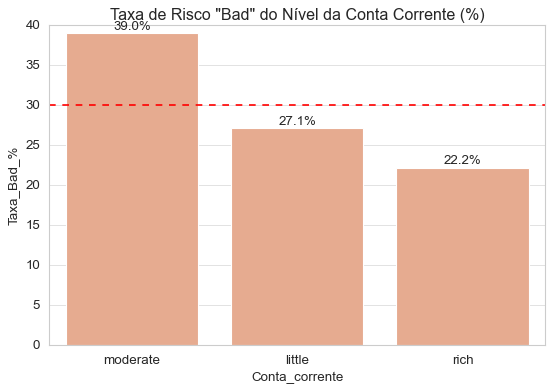

In [608]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

taxa_referencia = 30

# Cria o gráfico de barras agrupadas e ARMAZENA na variável 'ax'
ax = sns.barplot(
    x='Conta_corrente',
    y='Taxa_Bad_%',
    data=df_taxa_bad_corrente,
    color= '#F4A582'
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
)

# NOVO CÓDIGO: Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=1)

# Adiciona título e rótulos
plt.title('Taxa de Risco "Bad" do Nível da Conta Corrente (%)')
 
plt.show()

A categoria Moderate ultrapassou o limite de risco em 39%

##### Variável Finalidade:

1) Frequência Relativa %

In [609]:
# Porcentagem Relativa de Finalidade
percentual_finalidade = df1["Finalidade"].value_counts(normalize=True).round(3)*100

print("Porcentagem Relativa % de Finalidade:\n\n", percentual_finalidade)

Porcentagem Relativa % de Finalidade:

 Finalidade
car                    33.7
radio/TV               28.0
furniture/equipment    18.1
business                9.7
education               5.9
repairs                 2.2
domestic appliances     1.2
vacation/others         1.2
Name: proportion, dtype: float64


2) Frequência Acumulada %

In [610]:
# Frequência Acumulada %
freq_acum_finalidade = df1["Finalidade"].value_counts(normalize=True).cumsum().round(3)*100

print("Frequência Acumulada % de Finalidade:\n\n", freq_acum_finalidade)

Frequência Acumulada % de Finalidade:

 Finalidade
car                     33.7
radio/TV                61.7
furniture/equipment     79.8
business                89.5
education               95.4
repairs                 97.6
domestic appliances     98.8
vacation/others        100.0
Name: proportion, dtype: float64


3) Taxa de Risco por Categoria de Finalidade

In [611]:
# Taxa de Risco de Finalidade
taxa_risco_finalidade = df1.groupby(["Finalidade"])["Risco"].value_counts(normalize=True).round(3)*100

print("Taxa de Risco por Categoria de Finalidade:\n\n", taxa_risco_finalidade)

Taxa de Risco por Categoria de Finalidade:

 Finalidade           Risco
business             good     64.9
                     bad      35.1
car                  good     68.5
                     bad      31.5
domestic appliances  good     66.7
                     bad      33.3
education            good     61.0
                     bad      39.0
furniture/equipment  good     68.0
                     bad      32.0
radio/TV             good     77.9
                     bad      22.1
repairs              good     63.6
                     bad      36.4
vacation/others      good     58.3
                     bad      41.7
Name: proportion, dtype: float64


4) Taxa de Risco Bad

In [612]:
# Taxa de Risco Bad
taxa_bad_finalidade = df1.groupby(["Finalidade"])["Risco"].value_counts(normalize=True).sort_values(ascending=False).xs('bad', level="Risco").round(3)*100

print("Taxa de Risco Bad por Finalidade:\n\n", taxa_bad_finalidade)

Taxa de Risco Bad por Finalidade:

 Finalidade
vacation/others        41.7
education              39.0
repairs                36.4
business               35.1
domestic appliances    33.3
furniture/equipment    32.0
car                    31.5
radio/TV               22.1
Name: proportion, dtype: float64


5) Converter em Dataframe

In [613]:
#Converter em um dataframe
df_taxa_bad_finalidade = taxa_bad_finalidade.reset_index()

# Renomear as colunas
df_taxa_bad_finalidade.columns = ["Finalidade", "Taxa_Bad_%"]

print("Dataframe da Taxa de Risco Bad por Finalidade:\n\n", df_taxa_bad_finalidade)

Dataframe da Taxa de Risco Bad por Finalidade:

             Finalidade  Taxa_Bad_%
0      vacation/others        41.7
1            education        39.0
2              repairs        36.4
3             business        35.1
4  domestic appliances        33.3
5  furniture/equipment        32.0
6                  car        31.5
7             radio/TV        22.1


6) Visualização Gráfica da Taxa de Risco Bad por Categoria de Finalidade

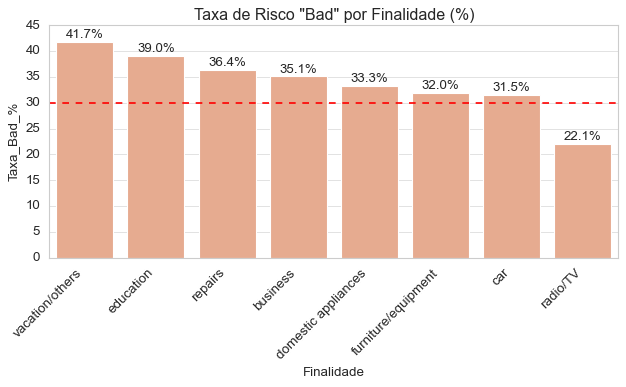

In [614]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

# Cria o gráfico de barras agrupadas e ARMAZENA na variável 'ax'
ax = sns.barplot(
    x='Finalidade',
    y='Taxa_Bad_%',
    data=df_taxa_bad_finalidade,
    color= '#F4A582'
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
    # Não precisa mais do 'label' aqui, pois o texto será direto
)

# Rotação dos rótulos do eixo X
plt.xticks(
    rotation=45,  # Define o ângulo de rotação (45 graus)
    ha='right'    # Alinha a base dos rótulos à direita para melhor encaixe
)


# Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=1)

# Adiciona título e rótulos
plt.title('Taxa de Risco "Bad" por Finalidade (%)')
plt.tight_layout() 
plt.show()

As categorias de finalidades vacation/others (41,7%), education (39,0%), repairs (36,4%) e business (35,1%) lideram os índices de Taxa Bad.<br>
Enquanto, as categorias domestic appliances (33,3%), furniture/equipment (32,0%) e car (31,5%) também ultrapassam o limite de risco, embora com margens menores.<br>
A única finalidade que apresenta um comportamento dento do limite é radio/TV, registrando apenas 22,1%.

##### Variável Idade:

1) Criar a Faixa Etaria

In [615]:
# 1) Vamos fazer uma engenharia de atributos no campo de IDADE e criar um novo campo de Faixa Etaria
print('Menor Idade:', df1['Idade'].min())
print('Maior Idade:', df1['Idade'].max())

Menor Idade: 19
Maior Idade: 75


In [616]:
# 2) Distribuição (Quantidade)
print(df1['Faixa_Etaria'].value_counts().sort_index())

Faixa_Etaria
19-28    334
29-38    346
39-48    181
49-58     85
59-68     47
69-78      7
Name: count, dtype: int64


In [617]:
# 3) Criar Variavel 
quantidade_fx_etaria = df1["Faixa_Etaria"].value_counts().sort_index(ascending=True)

quantidade_fx_etaria

Faixa_Etaria
19-28    334
29-38    346
39-48    181
49-58     85
59-68     47
69-78      7
Name: count, dtype: int64

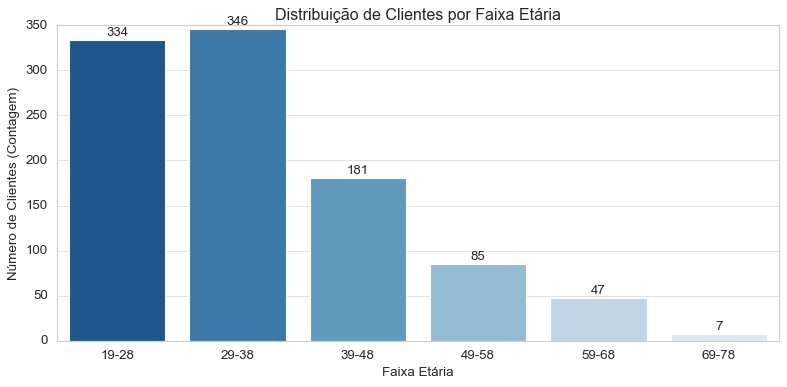

In [618]:
# 4) Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))

# Cria o gráfico de barras
ax = sns.countplot(
    x='Faixa_Etaria', 
    data=df1, 
    palette='Blues_r' # Uma paleta de cores para o gráfico
)

# Adiciona Rótulos de Dados (Contagem Absoluta)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1)

# Adiciona título e rótulos
plt.title('Distribuição de Clientes por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Clientes (Contagem)')

plt.tight_layout() 
plt.show()

2) Frequência Relativa %

In [619]:
# Porcentagem relativa % da Faixa Etaria
percentual_fx_etaria = df1["Faixa_Etaria"].value_counts(normalize=True).sort_index().round(3)*100

print("Porcentagem relativa % por Faixa Etaria:\n\n", percentual_fx_etaria)

Porcentagem relativa % por Faixa Etaria:

 Faixa_Etaria
19-28    33.4
29-38    34.6
39-48    18.1
49-58     8.5
59-68     4.7
69-78     0.7
Name: proportion, dtype: float64


3) Frequência Acumulada %

In [620]:
# Frequência Acumulada (%)
freq_acum_fx_etaria = df1["Faixa_Etaria"].value_counts(normalize=True).sort_index().cumsum().round(3)*100

print('Soma Acumulada por Faixa Etaria:\n\n', freq_acum_fx_etaria)

Soma Acumulada por Faixa Etaria:

 Faixa_Etaria
19-28     33.4
29-38     68.0
39-48     86.1
49-58     94.6
59-68     99.3
69-78    100.0
Name: proportion, dtype: float64


4) Taxa de Risco por Categoria de Faixa Etaria

In [621]:
# Taxa de Risco por Categoria de Faixa Etaria
taxa_risco_fx_etaria = df1.groupby(["Faixa_Etaria"])["Risco"].value_counts(normalize=True).round(3)*100

print("Taxa de Risco por categoria da Faixa Etaria:\n\n", taxa_risco_fx_etaria)

Taxa de Risco por categoria da Faixa Etaria:

 Faixa_Etaria  Risco
19-28         good     63.5
              bad      36.5
29-38         good     72.8
              bad      27.2
39-48         good     72.9
              bad      27.1
49-58         good     75.3
              bad      24.7
59-68         good     72.3
              bad      27.7
69-78         good     85.7
              bad      14.3
Name: proportion, dtype: float64


5) Taxa de Risco Bad

In [622]:
# Filtrar a Taxa de Risco Bad
taxa_bad_fx_etaria = df1.groupby(["Faixa_Etaria"])["Risco"].value_counts(normalize=True).xs("bad", level="Risco").round(3)*100

print("Taxa de Risco Bad por Faixa Etaria:\n\n", taxa_bad_fx_etaria)

Taxa de Risco Bad por Faixa Etaria:

 Faixa_Etaria
19-28    36.5
29-38    27.2
39-48    27.1
49-58    24.7
59-68    27.7
69-78    14.3
Name: proportion, dtype: float64


6) Taxa de Risco Good

In [623]:
# Filtrar a Taxa de Risco Good
taxa_good_fx_etaria = df1.groupby(["Faixa_Etaria"])["Risco"].value_counts(normalize=True).xs("good", level="Risco").round(3)*100

print("Taxa de Risco Good por Faixa Etaria:\n\n", taxa_good_fx_etaria)

Taxa de Risco Good por Faixa Etaria:

 Faixa_Etaria
19-28    63.5
29-38    72.8
39-48    72.9
49-58    75.3
59-68    72.3
69-78    85.7
Name: proportion, dtype: float64


7) Converter em Dataframe

In [624]:
# Converter em dataframe
df_taxa_bad_fx_etaria = taxa_bad_fx_etaria.reset_index()

# renomear as colunas
df_taxa_bad_fx_etaria.columns = ["Faixa_Etaria", "Taxa_Bad_%"]

print("Dataframe da Taxa de Risco Bad por Faixa Etaria:\n\n", df_taxa_bad_fx_etaria)

Dataframe da Taxa de Risco Bad por Faixa Etaria:

   Faixa_Etaria  Taxa_Bad_%
0        19-28        36.5
1        29-38        27.2
2        39-48        27.1
3        49-58        24.7
4        59-68        27.7
5        69-78        14.3


8) Visualização Gráfica da Taxa de Risco Bad por Faixa Etaria

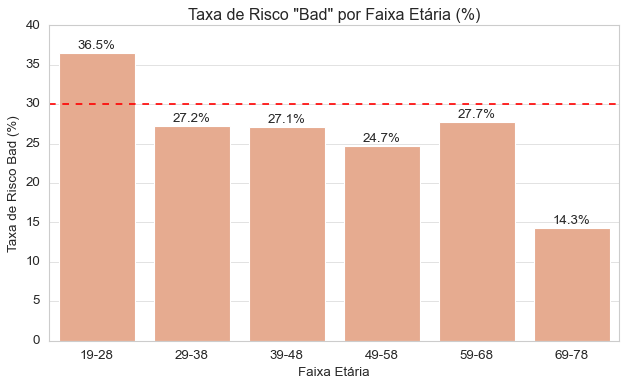

In [625]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

taxa_referencia = 30

# Cria o gráfico de barras
ax = sns.barplot(
    x='Faixa_Etaria',
    y='Taxa_Bad_%',
    data=df_taxa_bad_fx_etaria,
    color=cor_laranja_claro
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
)

# Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=1)


# Adiciona título e rótulos
plt.title('Taxa de Risco "Bad" por Faixa Etária (%)')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Risco Bad (%)')


# Ajusta o layout (o rect já não é tão crítico, mas mantém a organização)
plt.tight_layout() 
plt.show()

O grupo mais jovem (19-28 anos) é o único que excede o limite, registrando o maior risco com 36,5%.<br> Enquanto, a faixa de 69-78 anos apresenta a melhor performance, com apenas 14,3% de risco.

9) Criar um Novo Dataframe chamado (Analise_Faixa_Etaria) com todas as variáveis criadas!

In [626]:
# variáveis criadas como listas ou arrays - converter para Dataframe
Analise_Fx_Etaria = pd.DataFrame({
    "Quantidade": quantidade_fx_etaria,
    "%_Relativa": percentual_fx_etaria,
    "%_Acumulado": freq_acum_fx_etaria,
    "%_Taxa_Bad": taxa_bad_fx_etaria,
    "%_Taxa_Good":taxa_good_fx_etaria
})
Analise_Fx_Etaria

,Quantidade,%_Relativa,%_Acumulado,%_Taxa_Bad,%_Taxa_Good
Faixa_Etaria,,,,,
19-28,334,33.4,33.4,36.5,63.5
29-38,346,34.6,68.0,27.2,72.8
39-48,181,18.1,86.1,27.1,72.9
49-58,85,8.5,94.6,24.7,75.3
59-68,47,4.7,99.3,27.7,72.3
69-78,7,0.7,100.0,14.3,85.7


10) Agora Vamos Analisar a Faixa Etaria com o Valor de Crédito!

In [627]:
# 2) Agora Vamos Analisar a Faixa Etaria com o Valor de Crédito!
resumo_faixa = df1.groupby('Faixa_Etaria').agg(
    Quantidade=('Valor_credito', 'count'),
    Minimo_Credito=('Valor_credito', 'min'),
    Media_Credito=('Valor_credito', 'mean'),
    Maximo_Credito=('Valor_credito', 'max'),
    DesvPad=('Valor_credito', 'std')
).reset_index()

# Formatação de moeda
for col in ['Minimo_Credito', 'Media_Credito', 'Maximo_Credito', 'DesvPad']:
    resumo_faixa[col] = resumo_faixa[col].map(lambda x: f'R$ {x:,.2f}')

resumo_faixa

,Faixa_Etaria,Quantidade,Minimo_Credito,Media_Credito,Maximo_Credito,DesvPad
0,19-28,334,R$ 276.00,"R$ 3,042.36","R$ 15,672.00","R$ 2,672.24"
1,29-38,346,R$ 368.00,"R$ 3,407.61","R$ 18,424.00","R$ 2,774.37"
2,39-48,181,R$ 250.00,"R$ 3,487.01","R$ 15,857.00","R$ 2,968.04"
3,49-58,85,R$ 338.00,"R$ 3,093.46","R$ 15,945.00","R$ 2,910.39"
4,59-68,47,R$ 571.00,"R$ 3,240.13","R$ 14,896.00","R$ 3,470.88"
5,69-78,7,"R$ 1,299.00","R$ 4,242.71","R$ 7,308.00","R$ 2,359.94"


##### Variável Trabalho:

1) Frequência Relativa %

In [628]:
# Porcentagem Relativa %
percentual_trabalho = df1['Trabalho'].value_counts(normalize=True).sort_index().round(3)*100

print('Porcentagem Relativa % por Categoria de Trabalho:\n\n', percentual_trabalho)

Porcentagem Relativa % por Categoria de Trabalho:

 Trabalho
0     2.2
1    20.0
2    63.0
3    14.8
Name: proportion, dtype: float64


In [629]:
# Quantidade por Categoria de Trabalho
quantidade_trabalho = df1['Trabalho'].value_counts().sort_index()

print("Quantidade por Categoria de Trabalho:\n\n", quantidade_trabalho)

Quantidade por Categoria de Trabalho:

 Trabalho
0     22
1    200
2    630
3    148
Name: count, dtype: int64


2) Frequência Acumulada %

In [630]:
# Frequência Acumulada %
freq_acum_trabalho = df1['Trabalho'].value_counts(normalize=True).sort_index().cumsum().round(3)*100

print('Frequência Acumulada % de Trabalho:\n\n', freq_acum_trabalho)

Frequência Acumulada % de Trabalho:

 Trabalho
0      2.2
1     22.2
2     85.2
3    100.0
Name: proportion, dtype: float64


3) Taxa de Risco por Categoria de Trabalho

In [631]:
# Taxa de Risco de Trabalho
taxa_risco_trabalho = df1.groupby(['Trabalho'])['Risco'].value_counts(normalize=True).round(3)*100

print('Taxa de Risco de Trabalho:\n\n', taxa_risco_trabalho)

Taxa de Risco de Trabalho:

 Trabalho  Risco
0         good     68.2
          bad      31.8
1         good     72.0
          bad      28.0
2         good     70.5
          bad      29.5
3         good     65.5
          bad      34.5
Name: proportion, dtype: float64


4) Taxa de Risco Bad

In [632]:
# Taxa de Risco Bad
taxa_bad_trabalho = df1.groupby(['Trabalho'])["Risco"].value_counts(normalize=True).sort_index().xs('bad', level="Risco").round(3)*100

print('Taxa de Risco Bad por Categoria de Trabalho:\n\n', taxa_bad_trabalho)

Taxa de Risco Bad por Categoria de Trabalho:

 Trabalho
0    31.8
1    28.0
2    29.5
3    34.5
Name: proportion, dtype: float64


5) Taxa de Risco Good

In [633]:
# Taxa de Risco Good
taxa_good_trabalho = df1.groupby(["Trabalho"])["Risco"].value_counts(normalize=True).sort_index().xs("good", level="Risco").round(3)*100

print('Taxa de Risco Good por Categoria de Trabalho:\n\n', taxa_good_trabalho)

Taxa de Risco Good por Categoria de Trabalho:

 Trabalho
0    68.2
1    72.0
2    70.5
3    65.5
Name: proportion, dtype: float64


6) Converter em Dataframe

In [634]:
# Criar um dataframe para plotagem
df_taxa_bad_trabalho = taxa_bad_trabalho.reset_index()

# Renomear as colunas
df_taxa_bad_trabalho.columns = ['Trabalho', 'Taxa_Bad_%']

print("Dataframe da Taxa de Risco Bad por Categoria de Trabalho:\n\n", df_taxa_bad_trabalho)

Dataframe da Taxa de Risco Bad por Categoria de Trabalho:

    Trabalho  Taxa_Bad_%
0         0        31.8
1         1        28.0
2         2        29.5
3         3        34.5


7) Visualização Gráfica da Taxa de Risco Bad de Trabalho

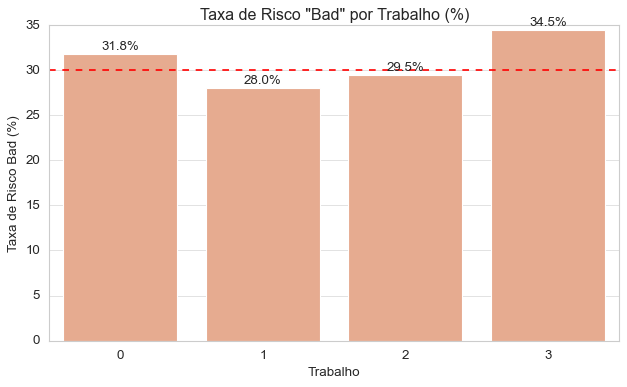

In [635]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

taxa_referencia = 30

# Cria o gráfico de barras
ax = sns.barplot(
    x='Trabalho',
    y='Taxa_Bad_%',
    data=df_taxa_bad_trabalho,
    color=cor_laranja_claro
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
)

# Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=1)


# Adiciona título e rótulos
plt.title('Taxa de Risco "Bad" por Trabalho (%)')
plt.xlabel('Trabalho')
plt.ylabel('Taxa de Risco Bad (%)')


# Ajusta o layout (o rect já não é tão crítico, mas mantém a organização)
plt.tight_layout() 
plt.show()

Dicionário:<br>
0 = Não qualificado e não residente<br>
1 = Não qualificado e residente<br>
2 = Qualificado (ou Especializado)<br>
3 = Altamente qualificado<br>

Os profissionais altamente qualificados (3) e os não qualificados não residentes (0) superam o limite de 30%, com riscos de 34,5% e 31,8%.<br> A maior segurança está nas categorias 1 e 2 (residentes e qualificados), que operam abaixo do limite com 28,0% e 29,5%.

8) Criar um Novo Dataframe chamado (Analise_trabalho) com todas as variáveis criadas!

In [636]:
Analise_Trabalho = pd.DataFrame({
  "Quantidade": quantidade_trabalho,
  "%_Relativa": percentual_trabalho,
  "%_Acumulado": freq_acum_trabalho,
  "%_Taxa_Bad": taxa_bad_trabalho,
  "%_Taxa_Good": taxa_good_trabalho 
})

Analise_Trabalho

,Quantidade,%_Relativa,%_Acumulado,%_Taxa_Bad,%_Taxa_Good
Trabalho,,,,,
0,22,2.2,2.2,31.8,68.2
1,200,20.0,22.2,28.0,72.0
2,630,63.0,85.2,29.5,70.5
3,148,14.8,100.0,34.5,65.5


9) Agora Vamos Analisar Trabalho com o Valor de Crédito!

In [637]:
Analise_credito_trabalho = df1.groupby('Trabalho').agg(
  Quantidade = ('Valor_credito', 'count'),
  Minimo_Credito = ('Valor_credito', 'min'),
  Media_Credito = ('Valor_credito', 'mean'),
  Maximo_Credito = ('Valor_credito', 'max'),
  DesvPad = ('Valor_credito', 'std')
).reset_index()

# Formatação de Moeda
for col in ['Minimo_Credito', 'Media_Credito', 'Maximo_Credito', 'DesvPad']:
  Analise_credito_trabalho[col] = Analise_credito_trabalho[col].map(lambda x: f'R$ {x:,.2f}')

Analise_credito_trabalho

,Trabalho,Quantidade,Minimo_Credito,Media_Credito,Maximo_Credito,DesvPad
0,0,22,R$ 609.00,"R$ 2,745.14","R$ 14,555.00","R$ 3,168.67"
1,1,200,R$ 250.00,"R$ 2,358.52","R$ 11,998.00","R$ 2,062.26"
2,2,630,R$ 338.00,"R$ 3,070.97","R$ 15,945.00","R$ 2,444.54"
3,3,148,R$ 629.00,"R$ 5,435.49","R$ 18,424.00","R$ 3,914.66"


##### Variável Duração:

1) Criar a Faixa de Duração

In [638]:
df1['Duracao'].describe().T

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duracao, dtype: float64

In [639]:
# Quantidade por faixa de Duração
quantidade_duracao = df1['Faixa_Duracao'].value_counts().sort_index()

print('Quantidade por Faixa de Duração:\n\n', quantidade_duracao)

Quantidade por Faixa de Duração:

 Faixa_Duracao
4-15     431
16-27    353
28-39    134
40-51     66
52-63     15
64-75      1
Name: count, dtype: int64


2) Frequência Relativa %

In [640]:
# Porcentagem relativa %
percentual_duracao = df1['Faixa_Duracao'].value_counts(normalize=True).round(3)*100

print('Porcentagem Relativa % por faixa de Duração:\n\n', percentual_duracao)

Porcentagem Relativa % por faixa de Duração:

 Faixa_Duracao
4-15     43.1
16-27    35.3
28-39    13.4
40-51     6.6
52-63     1.5
64-75     0.1
Name: proportion, dtype: float64


3) Frequência Acumulada %

In [641]:
# Frequência Acumulada %
freq_acum_duracao = df1['Faixa_Duracao'].value_counts(normalize=True).cumsum().sort_index().round(3)*100

print('Frequência Acumulada % por Faixa de Duração:\n\n', freq_acum_duracao)

Frequência Acumulada % por Faixa de Duração:

 Faixa_Duracao
4-15      43.1
16-27     78.4
28-39     91.8
40-51     98.4
52-63     99.9
64-75    100.0
Name: proportion, dtype: float64


4) Taxa de Risco de Duração

In [642]:
# Taxa de Risco por faixa de Duração
taxa_risco_duracao = df1.groupby(['Faixa_Duracao'])['Risco'].value_counts(normalize=True).sort_index().round(3)*100

print('Taxa de Risco por Faixa de Duração:\n\n', taxa_risco_duracao)

Taxa de Risco por Faixa de Duração:

 Faixa_Duracao  Risco
4-15           bad       20.6
               good      79.4
16-27          bad       32.3
               good      67.7
28-39          bad       39.6
               good      60.4
40-51          bad       54.5
               good      45.5
52-63          bad       46.7
               good      53.3
64-75          bad      100.0
               good       0.0
Name: proportion, dtype: float64


5) Taxa de Risco Bad

In [643]:
# Filtro para taxa de risco Bad
taxa_bad_duracao = df1.groupby(['Faixa_Duracao'])['Risco'].value_counts(normalize=True).xs("bad", level='Risco').sort_index().round(3)*100

print('Taxa de Risco Bad por Faixa de Duração:\n\n', taxa_bad_duracao)

Taxa de Risco Bad por Faixa de Duração:

 Faixa_Duracao
4-15      20.6
16-27     32.3
28-39     39.6
40-51     54.5
52-63     46.7
64-75    100.0
Name: proportion, dtype: float64


6) Taxa de Risco Good

In [644]:
# Filtro para Taxa de Risco Good
taxa_good_duracao = df1.groupby(['Faixa_Duracao'])['Risco'].value_counts(normalize=True).xs('good', level='Risco').sort_index().round(3)*100

print('Taxa de Risco good por Faixa de Duração:\n\n', taxa_good_duracao)

Taxa de Risco good por Faixa de Duração:

 Faixa_Duracao
4-15     79.4
16-27    67.7
28-39    60.4
40-51    45.5
52-63    53.3
64-75     0.0
Name: proportion, dtype: float64


7) Converter em Dataframe

In [645]:
# Criar um dataframe para plotagem
df_taxa_bad_duracao = taxa_bad_duracao.reset_index()

# Renomear as colunas
df_taxa_bad_duracao.columns = ['Duração', 'Taxa_Bad_%']

print('Dataset da Taxa de Risco Bad de Duração:\n\n', df_taxa_bad_duracao)

Dataset da Taxa de Risco Bad de Duração:

   Duração  Taxa_Bad_%
0    4-15        20.6
1   16-27        32.3
2   28-39        39.6
3   40-51        54.5
4   52-63        46.7
5   64-75       100.0


8) Visualização Gráfica da Taxa de Risco Bad de Duração

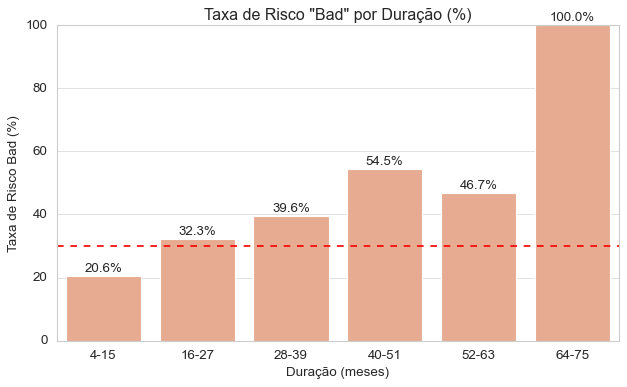

In [646]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

taxa_referencia = 30

# Cria o gráfico de barras
ax = sns.barplot(
    x='Duração',
    y='Taxa_Bad_%',
    data=df_taxa_bad_duracao,
    color=cor_laranja_claro
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
)

# Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=1)


# Adiciona título e rótulos
plt.title('Taxa de Risco "Bad" por Duração (%)')
plt.xlabel('Duração (meses)')
plt.ylabel('Taxa de Risco Bad (%)')


# Ajusta o layout (o rect já não é tão crítico, mas mantém a organização)
plt.tight_layout() 
plt.show()

O risco de crédito aumenta progressivamente com o tempo, ultrapassando a meta de 30% em todos os contratos acima de 16 meses.<br> 
O cenário mais crítico ocorre na faixa de 64-75 meses, onde a taxa de risco atinge o nível máximo de 100%.

9) Criar um Novo Dataframe chamado (Analise_Duração) com todas as variáveis criadas!

In [647]:
Analise_duracao = pd.DataFrame({
  "Quantidade": quantidade_duracao,
  "%_Relativa": percentual_duracao,
  "%_Acumulado": freq_acum_duracao,
  "%_Taxa_Bad": taxa_bad_duracao,
  "%_Taxa_Good": taxa_good_duracao
})

Analise_duracao

,Quantidade,%_Relativa,%_Acumulado,%_Taxa_Bad,%_Taxa_Good
Faixa_Duracao,,,,,
4-15,431,43.1,43.1,20.6,79.4
16-27,353,35.3,78.4,32.3,67.7
28-39,134,13.4,91.8,39.6,60.4
40-51,66,6.6,98.4,54.5,45.5
52-63,15,1.5,99.9,46.7,53.3
64-75,1,0.1,100.0,100.0,0.0


10) Agora Vamos Analisar de Duração com o Valor de Crédito!

In [648]:
Analise_credito_duracao = df1.groupby(['Faixa_Duracao']).agg(
  Quantidade = ('Valor_credito', 'count'),
  Minimo_Duração = ('Valor_credito', 'min'),
  Media_Duração = ('Valor_credito', 'mean'),
  Maximo_Duração = ('Valor_credito', 'max'),
  DesvPad = ('Valor_credito', 'std')
).reset_index()


# Formatar de moeda

for col in ['Minimo_Duração', 'Media_Duração', 'Maximo_Duração', 'DesvPad']:
    Analise_credito_duracao[col] = Analise_credito_duracao[col].map(
        lambda x: f'R$ {x:,.2f}' if pd.notnull(x) else 'R$ 0,00'
    )



Analise_credito_duracao

,Faixa_Duracao,Quantidade,Minimo_Duração,Media_Duração,Maximo_Duração,DesvPad
0,4-15,431,R$ 250.00,"R$ 1,887.46","R$ 14,896.00","R$ 1,554.53"
1,16-27,353,R$ 433.00,"R$ 3,135.51","R$ 12,976.00","R$ 2,112.76"
2,28-39,134,R$ 909.00,"R$ 5,431.16","R$ 15,857.00","R$ 3,137.97"
3,40-51,66,"R$ 1,845.00","R$ 7,007.85","R$ 18,424.00","R$ 3,353.15"
4,52-63,15,"R$ 6,288.00","R$ 10,336.00","R$ 15,945.00","R$ 3,550.90"
5,64-75,1,"R$ 5,595.00","R$ 5,595.00","R$ 5,595.00","R$ 0,00"


##### Variável Valor do Crédito:

1) Criar a Faixa de Crédito

In [649]:
df1['Valor_credito'].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Valor_credito, dtype: float64

2) Frequência Relativa %

In [650]:
# Porcentagem relativa %
percentual_credito = df1['Faixa_Credito'].value_counts(normalize=True).sort_index().round(3)*100

print('Porcentagem Relativa % de Crédito:\n\n', percentual_credito)

Porcentagem Relativa % de Crédito:

 Faixa_Credito
250-1249       19.4
1250-2249      29.2
2250-3249      17.2
3250-4249      11.2
4250-5249       5.5
5250-6249       3.6
6250-7249       4.1
7250-8249       3.3
8250-9249       1.5
9250-10249      1.3
10250-11249     0.9
11250-12249     0.9
12250-13249     0.6
13250-14249     0.3
14250-15249     0.5
15250-16249     0.4
16250-17249     0.0
17250-18249     0.0
18250-19249     0.1
Name: proportion, dtype: float64


3) Frequência Acumulada %

In [651]:
# Frequência Acumulada %
freq_acum_credito = df1['Faixa_Credito'].value_counts(normalize=True).sort_index().cumsum().round(3)*100

print('Frequência Acumulada % de Crédito:\n\n', freq_acum_credito)

Frequência Acumulada % de Crédito:

 Faixa_Credito
250-1249        19.4
1250-2249       48.6
2250-3249       65.8
3250-4249       77.0
4250-5249       82.5
5250-6249       86.1
6250-7249       90.2
7250-8249       93.5
8250-9249       95.0
9250-10249      96.3
10250-11249     97.2
11250-12249     98.1
12250-13249     98.7
13250-14249     99.0
14250-15249     99.5
15250-16249     99.9
16250-17249     99.9
17250-18249     99.9
18250-19249    100.0
Name: proportion, dtype: float64


4) Taxa de Risco do Valor de Crédito

In [652]:
# Taxa de Risco de Crédito
taxa_risco_credito = df1.groupby(['Faixa_Credito'])['Risco'].value_counts(normalize=True).sort_index().round(3)*100

print('Taxa de Risco de Crédito:\n\n', taxa_risco_credito)

Taxa de Risco de Crédito:

 Faixa_Credito  Risco
250-1249       bad       31.4
               good      68.6
1250-2249      bad       25.0
               good      75.0
2250-3249      bad       24.4
               good      75.6
3250-4249      bad       25.0
               good      75.0
4250-5249      bad       41.8
               good      58.2
5250-6249      bad       25.0
               good      75.0
6250-7249      bad       41.5
               good      58.5
7250-8249      bad       36.4
               good      63.6
8250-9249      bad       40.0
               good      60.0
9250-10249     bad       46.2
               good      53.8
10250-11249    bad       33.3
               good      66.7
11250-12249    bad       66.7
               good      33.3
12250-13249    bad       83.3
               good      16.7
13250-14249    bad       33.3
               good      66.7
14250-15249    bad      100.0
               good       0.0
15250-16249    bad       50.0
               good  

5) Taxa de Risco Bad

In [653]:
# Filtrar somente a Taxa de Risco Bad
taxa_bad_credito = df1.groupby(['Faixa_Credito'])['Risco'].value_counts(normalize=True).sort_index().xs('bad', level='Risco').round(3)*100

print('Taxa de Risco Bad de Crédito:\n\n', taxa_bad_credito)

Taxa de Risco Bad de Crédito:

 Faixa_Credito
250-1249        31.4
1250-2249       25.0
2250-3249       24.4
3250-4249       25.0
4250-5249       41.8
5250-6249       25.0
6250-7249       41.5
7250-8249       36.4
8250-9249       40.0
9250-10249      46.2
10250-11249     33.3
11250-12249     66.7
12250-13249     83.3
13250-14249     33.3
14250-15249    100.0
15250-16249     50.0
16250-17249      0.0
17250-18249      0.0
18250-19249    100.0
Name: proportion, dtype: float64


6) Taxa de Risco Good

In [654]:
# Filtrar somente a Taxa de Risco Good
taxa_good_credito = df1.groupby(['Faixa_Credito'])['Risco'].value_counts(normalize=True).sort_index().xs('good', level='Risco').round(3)*100

print('Taxa de Risco Good de Crédito:\n\n', taxa_good_credito)

Taxa de Risco Good de Crédito:

 Faixa_Credito
250-1249       68.6
1250-2249      75.0
2250-3249      75.6
3250-4249      75.0
4250-5249      58.2
5250-6249      75.0
6250-7249      58.5
7250-8249      63.6
8250-9249      60.0
9250-10249     53.8
10250-11249    66.7
11250-12249    33.3
12250-13249    16.7
13250-14249    66.7
14250-15249     0.0
15250-16249    50.0
16250-17249     0.0
17250-18249     0.0
18250-19249     0.0
Name: proportion, dtype: float64


7) Converter em Dataframe da Taxa de Risco Bad

In [655]:
# Criar dataframe para plotagem
df_taxa_bad_credito = taxa_bad_credito.reset_index()

# Renomar as colunas
df_taxa_bad_credito.columns = ['Faixa_Credito', '%_Taxa_Bad']

print('Dataframe da Taxa de Risco Bad de Crédito:\n\n', df_taxa_bad_credito)

Dataframe da Taxa de Risco Bad de Crédito:

    Faixa_Credito  %_Taxa_Bad
0       250-1249        31.4
1      1250-2249        25.0
2      2250-3249        24.4
3      3250-4249        25.0
4      4250-5249        41.8
5      5250-6249        25.0
6      6250-7249        41.5
7      7250-8249        36.4
8      8250-9249        40.0
9     9250-10249        46.2
10   10250-11249        33.3
11   11250-12249        66.7
12   12250-13249        83.3
13   13250-14249        33.3
14   14250-15249       100.0
15   15250-16249        50.0
16   16250-17249         0.0
17   17250-18249         0.0
18   18250-19249       100.0


8) Visualização Gráfica da Taxa de Risco Bad de Valor do Crédito

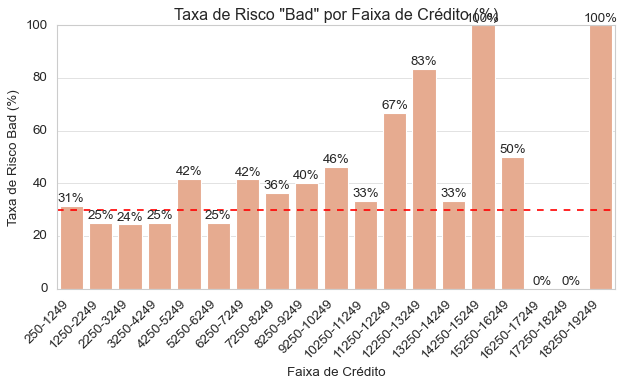

In [656]:
# Configuração visual
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

taxa_referencia = 30

# Cria o gráfico de barras
ax = sns.barplot(
    x='Faixa_Credito',
    y='%_Taxa_Bad',
    data=df_taxa_bad_credito,
    color=cor_laranja_claro
)

# Adiciona a Linha Horizontal Pontilhada em 30%
ax.axhline(
    taxa_referencia,
    color='r',
    linestyle='--',
    linewidth=1.5,
)

# Adiciona os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=1)


# Rotação dos rótulos do eixo X
plt.xticks(
    rotation=45,  # Define o ângulo de rotação (45 graus)
    ha='right'    # Alinha a base dos rótulos à direita para melhor encaixe
)


# Adiciona título e rótulos
plt.title('Taxa de Risco "Bad" por Faixa de Crédito (%)')
plt.xlabel('Faixa de Crédito')
plt.ylabel('Taxa de Risco Bad (%)')


# Ajusta o layout (o rect já não é tão crítico, mas mantém a organização)
plt.tight_layout() 
plt.show()

As taxas de risco tornam-se críticas e instáveis em faixas de crédito mais altas, atingindo 100% nos intervalos de (14250-15249) e acima de (18250).<br> A maior estabilidade e segurança concentram-se em valores baixos, especificamente entre (1250 e 4249), que mantêm o risco abaixo da meta de 30%.

9) Criar um Novo Dataframe chamado (Analise_credito) com todas as variáveis criadas!

In [657]:
Analise_credito_1 = pd.DataFrame({
  "Quantidade": quantidade_credito,
  "%_Relativa": percentual_credito,
  "%_Acumulado": freq_acum_credito,
  "%_Taxa_Bad": taxa_bad_credito,
  "%_Taxa_Good":taxa_good_credito
}).sort_index()

Analise_credito_1

,Quantidade,%_Relativa,%_Acumulado,%_Taxa_Bad,%_Taxa_Good
Faixa_Credito,,,,,
250-1249,194,19.4,19.4,31.4,68.6
1250-2249,292,29.2,48.6,25.0,75.0
2250-3249,172,17.2,65.8,24.4,75.6
3250-4249,112,11.2,77.0,25.0,75.0
4250-5249,55,5.5,82.5,41.8,58.2
5250-6249,36,3.6,86.1,25.0,75.0
6250-7249,41,4.1,90.2,41.5,58.5
7250-8249,33,3.3,93.5,36.4,63.6
8250-9249,15,1.5,95.0,40.0,60.0


10) Agora Vamos Analisar Valor do Crédito com o Risco!

In [658]:
Analise_credito = df1.groupby(['Faixa_Credito']).agg(
  Quantidade = ('Valor_credito', 'count'),
  Minimo_Credito = ('Valor_credito', 'min'),
  Media_Credito = ('Valor_credito', 'mean'),
  Maximo_Credito = ('Valor_credito', 'max'),
  DesvPad = ('Valor_credito', 'std')
)

# Formatação da Moeda

for col in ['Minimo_Credito','Media_Credito','Maximo_Credito','DesvPad']:
 Analise_credito[col] =  Analise_credito[col].map(lambda x: f'R$ {x:,.2f}' if pd.notnull(x) else 'R$ 0,00')



Analise_credito

,Quantidade,Minimo_Credito,Media_Credito,Maximo_Credito,DesvPad
Faixa_Credito,,,,,
250-1249,194,R$ 250.00,R$ 897.76,"R$ 1,249.00",R$ 260.60
1250-2249,292,"R$ 1,255.00","R$ 1,672.22","R$ 2,249.00",R$ 304.40
2250-3249,172,"R$ 2,251.00","R$ 2,707.92","R$ 3,249.00",R$ 291.72
3250-4249,112,"R$ 3,275.00","R$ 3,710.60","R$ 4,249.00",R$ 257.72
4250-5249,55,"R$ 4,272.00","R$ 4,717.55","R$ 5,248.00",R$ 288.58
5250-6249,36,"R$ 5,293.00","R$ 5,819.31","R$ 6,229.00",R$ 293.75
6250-7249,41,"R$ 6,260.00","R$ 6,680.93","R$ 7,238.00",R$ 304.67
7250-8249,33,"R$ 7,253.00","R$ 7,679.36","R$ 8,229.00",R$ 273.62
8250-9249,15,"R$ 8,318.00","R$ 8,682.20","R$ 9,157.00",R$ 295.23


### 6º Etapa: Insights Extraídos da Análise Exploratória (EDA)

Resumo: Análise Segmentada dos Clientes - apenas as categorias que ultrapassaram a Taxa Geral Bad (30%)
- Genero: feminino (35,20%) <br>

- Habitação: free (40,70%) e rent (39,10%) <br>

- Poupança: little (31,70%) e moderate (33%) <br>

- Corrente: moderate (39%) <br>

- Finalidade: vacation/others (41,7%), education (39,0%), repairs (36,4%), business (35,1%), domestic app (33,3%), furniture/equip (32,0%) e car (31,5%) <br>

- Faixa_etaria: De 19-28 (36,5%) <br>

- Trabalho: 0= não qualificado|não residente (31,8%) e 3= altamente qualificado (34,5%) <br>

- Duração: Acima De 16 até 75 meses  <br>

- Valor de Crédito: As Faixas De 250 | 4250 | 6250 até 19249 <br>

Análise Detalhada do Perfil de Crédito de Clientes:

- Gênero <br>	
  Distribuição: O portfólio de clientes é majoritariamente masculino (69%) <br>										
  Taxa de Risco: As mulheres apresentam uma taxa de risco "Bad" 7,5 p.p. mais alta do que os homens	<br>											
  Volume Crédito: A média de crédito concedida aos homens é 19,87% maior do que a média de crédito concedida às mulheres. <br>
  <br>
- Idade	<br>	
  Distribuição: O portfólio é concentrado por clientes jovens (19-38 anos) <br>											
  Taxa de Risco: A faixa etária mais jovem (19-28 anos) apresenta a maior Taxa de Risco (35,53%), sendo a única que está acima da Taxa Geral (30%)	<br>											
  Volume Crédito: O grupo de maior risco (19-28 anos) tem o menor crédito médio, e o grupo de menor risco (69-78 anos) tem o maior crédito médio, indicando uma gestão de risco consistente.	<br>
  <br>											
- Habitação	<br>	
  Distribuição: A maior concentração dos clientes (71,30%) tem Moradia Própria (Own). <br>												
  Taxa de Risco: Clientes com Moradia "Free" (40,74%) e "Rent" (39,11%) são os grupos de maior risco, com taxas cerca de 13 a 14 pontos percentuais (p.p.) superiores à Moradia Própria. <br>											
  Volume Crédito: O grupo de Maior Risco ("Free" 40,74%) é o que recebe a maior Média de Crédito (R$ 4.906). Os clientes com Moradia Própria (Own), apesar de serem o grupo de menor risco (26,09%) e a maioria, recebem o menor volume médio de crédito (R$ 3.061). <br>
  <br>
- Trabalho	<br>	
  Distribuição: A maior concentração dos clientes (63%) está no Nível de Trabalho 2.<br>												
  Taxa de Risco: Nível 0 e 3 apresenta a maior Taxa de Risco (31,82% e 34,46%), estando acima da Média Geral (30%).<br>												
  Volume Crédito: Nível 3 é o grupo de maior risco (34,46%), mas também recebe o maior volume de crédito (R$ 5.435). O Nível 1 é o grupo de menor risco (28,00%), mas recebe o menor volume de crédito (R$ 2.359)	<br>
  <br>
- Poupança	<br>	
  Distribuição: A maior concentração dos clientes (78,60%) está no nível "little" (pouca) de conta poupança.<br>												
  Taxa de Risco: Os níveis "little" (31,68%) e "moderate" (33,01%) têm taxas de risco acima da Média Geral (30%). <br>												
  Volume Crédito: O grupo de Menor Risco ("rich" - 15,32%) recebe o menor volume médio de crédito (R$ 2.573) | Os grupos de Maior Risco ("little" e "moderate") recebem um volume de crédito médio maior (R$ 3.355 e R$ 3.384).<br>
  <br>
- Corrente	<br>	
  Distribuição: A maior concentração dos clientes (66,80%) tem um nível "little" (baixo) na conta corrente. O nível "moderate" é a segunda maior fatia (26,90%)	<br>											
  Taxa de Risco: O nível "moderate" apresenta a maior Taxa de Risco (39,03%), ficando muito acima da Média Geral (30%).	<br>											
  Volume Crédito: O grupo de Maior Risco ("moderate" - 39,03%) recebe o maior volume médio de crédito (R$ 3.828) | O grupo de Menor Risco ("rich" - 22,22%) recebe o menor volume médio de crédito (R$ 2.178) <br>												
  Tendência: Assim como na Conta Poupança, o nível de conta corrente parece ter uma relação inversa entre risco e valor do crédito: o grupo mais seguro recebe o menor volume.	<br>
  <br>
- Valor Crédito	<br>	
  Distribuição: A maior concentração dos clientes (29,2%), esta na faixa de (1250-2249), seguida por (19,4%) na faixa de (250-1249) e (17,2%) na faixa de (2250-3249) | A maioria dos clientes (quase 66%) recebe crédito até R$ 3249 <br>												
  Taxa de Risco: A faixa (2250-3249) apresenta o menor risco (24%) | Nas faixas de crédito muito alto, atingindo 100% nas faixas (14.250-15.249 e 18.250-19.249) <br>												
  Volume Crédito: Os créditos de baixo valor (abaixo de R$ 3.249), que representam a maioria dos clientes, têm um risco relativamente baixo (24% a 31%)	<br>
  <br>
- Finalidade <br>		
  Distribuição: As categorias "car" (33,7%), "radio/TV" (28,0%) e "furniture/equip" (18,1%) consolidam a maior parte do negócio, somando 79,8% do volume total. <br>												
  Taxa de Risco: O crédito para "radio/TV" apresenta o menor risco (22,1%), sendo o mais seguro entre todas as finalidades | O crédito para "vacation/others" (férias/outros) apresenta o maior risco (41,7%) | O principal grupo ("car" - 33,7%) tem um risco ligeiramente acima da média (31,5%).	<br>											
  Volume Crédito: A finalidade de Maior Risco ("vacation/others" - 41,7%) recebe o maior Valor Médio de Crédito (R$ 8.209), que é mais que o dobro da média de muitas outras finalidades | A finalidade de Menor Risco ("radio/TV" - 22,1%) está entre as que recebem o menor volume de crédito (R$ 2.488) | Negócios/Carro: Créditos para "business" (R$ 4.158) e "car" (R$ 3.768) têm volumes médios razoáveis.<br>
  <br>
- Duração	<br>	
  Distribuição: A grande maioria dos clientes (78,4%) opta por prazos de curta duração (até 27 meses). A faixa de 4-15 meses sozinha concentra 43,1% dos clientes.<br>											
  Taxa de Risco: O menor prazo (4-15 meses) apresenta o menor risco (21%), confirmando que o risco de inadimplência aumenta significativamente com o alongamento do prazo | O maior prazo (64-75 meses) atinge um risco de 100% | O risco aumenta acentuadamente de 21% para 55% à medida que o prazo se estende até 51 meses.<br>											
  Volume Crédito: O maior volume médio (R$ 10.336) ocorre na faixa de 52-63 meses, que já tem um risco de 47%.
  O menor volume (R$ 1.887) está no grupo de menor risco (4-15 meses). | O volume de crédito aumenta drasticamente com o prazo, pois prazos mais longos são necessários para acomodar valores maiores.	<br>

### 7º Etapa: Feature Engineering

Feature Engineering - consiste na transformação das variáveis para melhorar a análise dos dados. Nesta etapa, é aplicada a técnica de binning, na qual variáveis numéricas são agrupadas em faixas. <br>

Neste conjunto de dados, o binning é aplicado às variáveis Idade, Duração do crédito e Valor do crédito, permitindo agrupar clientes com características semelhantes e facilitar a análise do risco de crédito.<br>

Aplica binning nas variáveis:

- Idade → Faixa_Etaria <br>

- Duracao → Faixa_Duracao <br>

- Valor_credito → Faixa_Credito <br>

In [659]:
# ==================================================
# 7º Etapa — Feature Engineering
# ==================================================

# Criar dataset para modelagem
df_final = df1.copy()

# -----------------------------------------
# Binning das variáveis numéricas
# -----------------------------------------

# Faixa de Idade
df_final['Faixa_Etaria'] = pd.cut(
    df_final['Idade'],
    bins=[19,29,39,49,59,69,79],
    labels=['19-28','29-38','39-48','49-58','59-68','69-78'],
    include_lowest=True
)

# Faixa de Duração do Crédito
df_final['Faixa_Duracao'] = pd.cut(
    df_final['Duracao'],
    bins=[4,16,28,40,52,64,76],
    labels=['4-15','16-27','28-39','40-51','52-63','64-75'],
    include_lowest=True
)

# Faixa de Valor do Crédito
df_final['Faixa_Credito'] = pd.cut(
    df_final['Valor_credito'],
    bins=[250,1250,2250,3250,4250,5250,6250,7250,8250,9250,
          10250,11250,12250,13250,14250,15250,16250,17250,18250,19250],
    labels=['250-1249','1250-2249','2250-3249','3250-4249','4250-5249',
            '5250-6249','6250-7249','7250-8249','8250-9249','9250-10249',
            '10250-11249','11250-12249','12250-13249','13250-14249',
            '14250-15249','15250-16249','16250-17249','17250-18249','18250-19249'],
    include_lowest=True
)

# -----------------------------------------
# Verificar se existem NaN nas faixas
# -----------------------------------------

print(df_final[['Faixa_Etaria','Faixa_Duracao','Faixa_Credito']].isnull().sum())

# Visualização
df_final[['Idade','Faixa_Etaria','Duracao','Faixa_Duracao','Valor_credito','Faixa_Credito']].head()

# -----------------------------------------
# Remover variáveis numéricas originais
# -----------------------------------------

df_final = df_final.drop(columns=['Unnamed: 0','Idade','Duracao','Valor_credito'])

# Visualização do dataset atualizado
df_final.head()

Faixa_Etaria     0
Faixa_Duracao    0
Faixa_Credito    0
dtype: int64


,Genero,Trabalho,Habitação,Conta_poupança,Conta_corrente,Finalidade,Risco,Faixa_Etaria,Faixa_Duracao,Faixa_Credito
0,male,2,own,little,little,radio/TV,good,59-68,4-15,250-1249
1,female,2,own,little,moderate,radio/TV,bad,19-28,40-51,5250-6249
2,male,1,own,little,little,education,good,39-48,4-15,1250-2249
3,male,2,free,little,little,furniture/equipment,good,39-48,40-51,7250-8249
4,male,2,free,little,little,car,bad,49-58,16-27,4250-5249


### 8️º Etapa: Feature Selection com WOE e Information Value (IV)

Nesta etapa é aplicada a técnica WOE (Weight of Evidence), utilizada para analisar a relação entre as variáveis explicativas e a variável alvo de risco de crédito. O método calcula, para cada categoria ou faixa das variáveis, a proporção entre bons (good) e maus (bad) pagadores, permitindo avaliar o poder de separação dessas categorias em relação ao risco. <br>

A partir desses resultados também é calculado o IV (Information Value), métrica utilizada para medir a importância preditiva de cada variável. Com base no IV é possível identificar quais variáveis apresentam maior relevância para o modelo de risco de crédito e, consequentemente, apoiar o processo de seleção de variáveis.

In [660]:
# ==================================================
# 8º Etapa — WOE + IV
# ==================================================

import scorecardpy as sc
import pandas as pd

# -----------------------------------------
# Dataset para cálculo WOE
# -----------------------------------------

df_woe = df_final.copy()

# Remover variáveis originais após binning
df_woe = df_woe.drop(
    columns=['Idade','Duracao','Valor_credito','Unnamed: 0'],
    errors='ignore'
)

# -----------------------------------------
# Binning + cálculo WOE
# -----------------------------------------

bins = sc.woebin(df_woe, y="Risco")

# -----------------------------------------
# Tabela completa de WOE
# -----------------------------------------

woe_table = pd.concat(bins.values())

# Mostrar apenas primeiras linhas
display(woe_table.head())

# -----------------------------------------
# Ranking de variáveis por IV
# -----------------------------------------

ranking_iv = (
    woe_table[['variable','total_iv']]
    .drop_duplicates()
    .sort_values(by='total_iv', ascending=False)
    .reset_index(drop=True)
)

display(ranking_iv)

[INFO] creating woe binning ...


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,Genero,male,690,0.690,499,191,0.276812,-0.113035,0.008612,0.026543,male,False
1,Genero,female,310,0.310,201,109,0.351613,0.235341,0.017931,0.026543,female,False
0,Faixa_Duracao,4-15,433,0.433,343,90,0.207852,-0.490623,0.093218,0.212092,4-15,False
1,Faixa_Duracao,16-27,354,0.354,240,114,0.322034,0.102857,0.003820,0.212092,16-27,False
2,Faixa_Duracao,28-39,132,0.132,79,53,0.401515,0.448142,0.028596,0.212092,28-39,False


,variable,total_iv
0,Faixa_Duracao,0.212092
1,Faixa_Credito,0.139230
2,Habitação,0.083293
3,Conta_poupança,0.073979
4,Conta_corrente,0.069069
5,Finalidade,0.066952
6,Faixa_Etaria,0.063702
7,Genero,0.026543
8,Trabalho,0.008095


### 9º Etapa: Pré-Processamento dos Dados

Nesta etapa é realizado o pré-processamento dos dados para preparação da base utilizada na modelagem. Inicialmente, as variáveis selecionadas na etapa anterior são transformadas utilizando a técnica WOE (Weight of Evidence), que converte categorias ou faixas em valores numéricos baseados na relação entre bons e maus pagadores. Essa transformação é amplamente utilizada em modelos de risco de crédito por facilitar a interpretação estatística e melhorar a capacidade preditiva do modelo.<br>

Após a transformação WOE, a base de dados é dividida em conjuntos de treino e teste, utilizando o parâmetro *stratify* para preservar a proporção original das classes da variável alvo em ambos os conjuntos. <br>

Por fim, é aplicado o balanceamento da base de treinamento utilizando a técnica SMOTE (Synthetic Minority Over-sampling Technique), que gera amostras sintéticas da classe minoritária quando há desbalanceamento entre as classes, reduzindo possíveis vieses durante o treinamento do modelo.


- WOE Transformation → transformação das variáveis em valores WOE para representação numérica no modelo. <br>

- Train/Test Split → divisão da base em treino e teste preservando a proporção das classes. <br>

- SMOTE → balanceamento da base de treino através da geração de amostras sintéticas da classe minoritária. <br>

In [661]:
# ==================================================
# 9º Etapa — Pré-Processamento
# ==================================================

import scorecardpy as sc
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# -----------------------------------------
# Transformação WOE
# -----------------------------------------

df_woe = sc.woebin_ply(df_final, bins)

# -----------------------------------------
# Converter variável alvo para numérica
# -----------------------------------------

df_woe['Risco'] = df_woe['Risco'].map({'good':1, 'bad':0})

# -----------------------------------------
# Separação variáveis preditoras e alvo
# -----------------------------------------

X = df_woe.drop('Risco', axis=1)
y = df_woe['Risco']

# -----------------------------------------
# Divisão treino / teste (stratify)
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

# -----------------------------------------
# Balanceamento SMOTE (apenas treino)
# -----------------------------------------

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# -----------------------------------------
# Verificação das dimensões
# -----------------------------------------

print("Dimensão treino original:", X_train.shape)
print("Dimensão treino após SMOTE:", X_train_bal.shape)
print("Dimensão teste:", X_test.shape)

# -----------------------------------------
# Distribuição das classes
# -----------------------------------------

print("\nDistribuição antes do SMOTE:")
print(y_train.value_counts())

print("\nDistribuição após SMOTE:")
print(y_train_bal.value_counts())

[INFO] converting into woe values ...
Dimensão treino original: (700, 9)
Dimensão treino após SMOTE: (980, 9)
Dimensão teste: (300, 9)

Distribuição antes do SMOTE:
Risco
1    490
0    210
Name: count, dtype: int64

Distribuição após SMOTE:
Risco
1    490
0    490
Name: count, dtype: int64


### 10º Etapa: Análise de Correlação e Multicolinearidade

Foi realizada a análise de correlação entre as variáveis preditoras com o objetivo de verificar a presença de multicolinearidade. Os resultados indicaram correlações baixas entre as variáveis, não sendo identificadas associações que possam comprometer a estabilidade do modelo. <br>

Também foi analisada a correlação entre as variáveis preditoras e a variável alvo (Risco), permitindo avaliar o grau de associação entre os preditores e o comportamento de inadimplência. <br>

Adicionalmente, foi calculado o VIF (Variance Inflation Factor) para avaliar a presença de multicolinearidade entre as variáveis explicativas. Os valores encontrados foram próximos de 1 para todas as variáveis, indicando ausência de multicolinearidade relevante e confirmando que o conjunto de variáveis está adequado para a etapa de modelagem. <br>

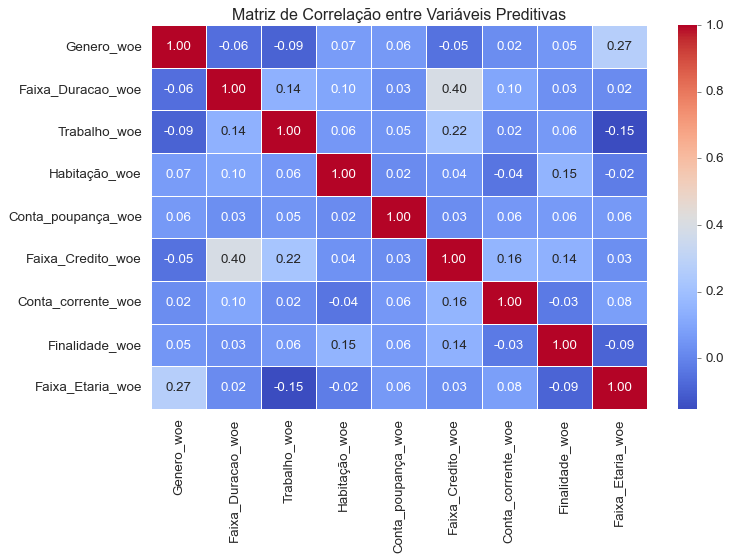

In [662]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==================================================
# Correlação entre variáveis preditoras
# ==================================================

corr_matrix = X_train_bal.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação entre Variáveis Preditivas")

plt.show()

 Tabela de Referência — Interpretação da Correlação
| Correlação  | Interpretação |
|---|---|
| 0 – 0.30 | Fraca |
| 0.30 – 0.70 | Moderada |
| 0.70 – 0.90 | Forte |
| > 0.90 | Muito forte (possível multicolinearidade) |

Ranking — Maiores Correlações entre Preditoras

- Faixa_Duracao_woe × Faixa_Credito_woe ≈ 0.40 <br>
- Genero_woe × Faixa_Etaria_woe ≈ 0.27 <br>
- Faixa_Credito_woe × Trabalho_woe ≈ 0.22 <br>
- Conta_corrente_woe × Faixa_Credito_woe ≈ 0.16 <br>
- Finalidade_woe × Habitação_woe ≈ 0.15 <br>
- Faixa_Etaria_woe × Trabalho_woe ≈ 0.15 (Correlação negativa de -0.15) <br>
- Faixa_Duracao_woe × Trabalho_woe ≈ 0.14 <br>
- Finalidade_woe × Faixa_Credito_woe ≈ 0.14 <br>
- Faixa_Duracao_woe × Conta_corrente_woe ≈ 0.10 <br>
- Faixa_Duracao_woe × Habitação_woe ≈ 0.10 <br>

Interpretação:

A análise das correlações entre as variáveis preditoras mostrou valores baixos a moderados, sendo a maior correlação 0.40 entre Faixa_Duracao_woe e Faixa_Credito_woe. 
As demais correlações apresentaram valores inferiores a 0.30, indicando associações fracas entre as variáveis. Esses resultados sugerem baixa multicolinearidade, não sendo necessária a remoção de variáveis nesta etapa da modelagem.

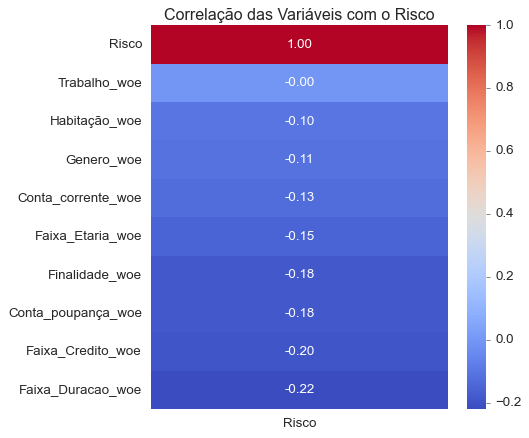

In [663]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------
# Dataset com preditoras + target
# -----------------------------------------

df_corr_target = pd.concat([X_train_bal, y_train_bal], axis=1)

# -----------------------------------------
# Correlação com target
# -----------------------------------------

corr_target = df_corr_target.corr()[["Risco"]].sort_values(by="Risco", ascending=False)

# -----------------------------------------
# Heatmap
# -----------------------------------------

plt.figure(figsize=(6,6))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação das Variáveis com o Risco")

plt.show()

Interpretação:

A análise mostrou que todas as variáveis apresentam correlação negativa e de baixa magnitude com a variável alvo (Risco). As maiores associações foram observadas em Faixa_Duracao_woe (-0.22) e Faixa_Credito_woe (-0.20). <br> 

De forma geral, os valores baixos são esperados após a transformação WOE, indicando ausência de relação linear forte com o risco de crédito.

In [664]:
# ==================================================
# Cálculo do VIF
# ==================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Variavel"] = X_train_bal.columns

vif["VIF"] = [
    variance_inflation_factor(X_train_bal.values, i)
    for i in range(X_train_bal.shape[1])
]

vif = vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\nRanking VIF:")
print(vif.head(15))


Ranking VIF:
             Variavel       VIF
0   Faixa_Credito_woe  1.282515
1   Faixa_Duracao_woe  1.210688
2    Faixa_Etaria_woe  1.129292
3          Genero_woe  1.105710
4        Trabalho_woe  1.093510
5      Finalidade_woe  1.066146
6       Habitação_woe  1.043020
7  Conta_corrente_woe  1.039805
8  Conta_poupança_woe  1.017038


 Tabela de Referência — Interpretação do VIF

| <div align="center">Valor do VIF</div> | <div align="center">Interpretação</div> |
|:---:|:---:|
| VIF = 1 | Não existe multicolinearidade |
| 1 < VIF < 5 | Multicolinearidade baixa (aceitável) |
| 5 ≤ VIF < 10 | Multicolinearidade moderada (atenção) |
| VIF ≥ 10 | Multicolinearidade alta (recomenda-se remover ou revisar variáveis) |

Interpretação:

A análise do VIF - mostrou que todas as variáveis apresentam valores próximos de 1, variando entre 1.01 e 1.28. <br>
Esses resultados indicam ausência de multicolinearidade relevante entre as variáveis preditoras. Portanto, o conjunto de variáveis está adequado para a etapa de modelagem, sem necessidade de remoção adicional.

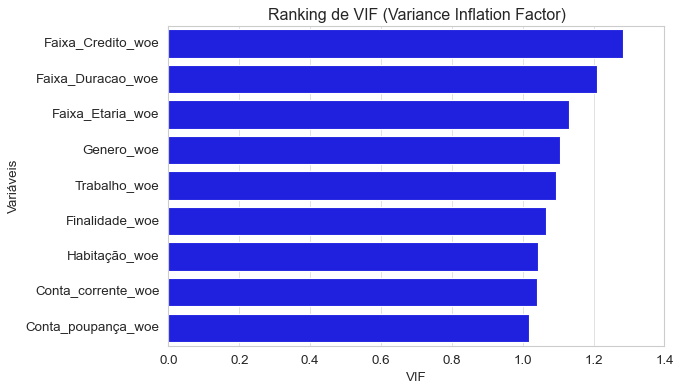

In [665]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------
# Gráfico Ranking VIF
# -----------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data = vif.head(15),
    x = "VIF",
    y = "Variavel"
)

plt.title("Ranking de VIF (Variance Inflation Factor)")
plt.xlabel("VIF")
plt.ylabel("Variáveis")

plt.show()

In [666]:
# -----------------------------------------
# Manter apenas variáveis WOE + target
# -----------------------------------------

df_model = df_woe.filter(regex='_woe|Risco')

# -----------------------------------------
# Verificação da estrutura
# -----------------------------------------

print("Dimensão do dataset:")
print(df_model.shape)

print("\nColunas utilizadas no modelo:")
print(df_model.columns)

# Visualização
df_model.head()

Dimensão do dataset:
(1000, 10)

Colunas utilizadas no modelo:
Index(['Risco', 'Genero_woe', 'Faixa_Duracao_woe', 'Trabalho_woe',
       'Habitação_woe', 'Conta_poupança_woe', 'Faixa_Credito_woe',
       'Conta_corrente_woe', 'Finalidade_woe', 'Faixa_Etaria_woe'],
      dtype='object')


,Risco,Genero_woe,Faixa_Duracao_woe,Trabalho_woe,Habitação_woe,Conta_poupança_woe,Faixa_Credito_woe,Conta_corrente_woe,Finalidade_woe,Faixa_Etaria_woe
0,1,-0.113035,-0.490623,-0.022780,-0.194156,0.078753,0.067823,-0.142469,-0.410063,-0.137201
1,0,0.235341,0.970912,-0.022780,-0.194156,0.078753,0.237038,0.401392,-0.410063,0.311958
2,1,-0.113035,-0.490623,-0.078472,-0.194156,0.078753,-0.260595,-0.142469,0.418302,-0.219816
3,1,-0.113035,0.970912,-0.022780,0.472604,0.078753,0.237038,-0.142469,0.079618,-0.219816
4,0,-0.113035,0.102857,-0.022780,0.472604,0.078753,0.517056,-0.142469,0.079618,-0.137201


### 11º Etapa: Modelagem dos Dados - Modelo Baseline

Foi desenvolvido um modelo baseline para servir como referência de desempenho, utilizando regressão logística, técnica amplamente aplicada em problemas de credit scoring devido à sua interpretabilidade e à capacidade de estimar probabilidades de inadimplência. <br>

Subetapas:

- Instanciação do modelo: criação da regressão logística como algoritmo base.

- Treinamento do modelo: ajuste do modelo utilizando os dados de treino balanceados (SMOTE).

In [667]:
# ==================================================
# MODELO BASELINE — REGRESSÃO LOGÍSTICA
# ==================================================

from sklearn.linear_model import LogisticRegression

# -----------------------------------------
# INSTANCIAR MODELO
# -----------------------------------------
modelo_log = LogisticRegression(max_iter=1000)

# -----------------------------------------
# TREINAR MODELO
# -----------------------------------------
modelo_log.fit(X_train_bal, y_train_bal)

LogisticRegression(max_iter=1000)

### 12º Etapa: Avaliação do Modelo

Nesta etapa é realizada uma avaliação mais detalhada do desempenho do modelo, utilizando métricas aplicadas em problemas de risco de crédito. 
Além das métricas tradicionais de classificação, são analisados indicadores como AUC, Gini e KS Statistic, que permitem avaliar a capacidade do modelo em diferenciar bons e maus pagadores. <br>

Essas métricas fornecem uma visão mais completa do poder discriminatório do modelo e permitem validar se o desempenho obtido é adequado para o problema. Os resultados também servem como referência para possíveis ajustes ou comparação com modelos mais avançados em etapas posteriores do projeto.

Acurácia:
0.6233333333333333

Gini:
0.28788359788359763

ROC AUC:
0.6439417989417988

KS Statistic:
0.2190476190476191


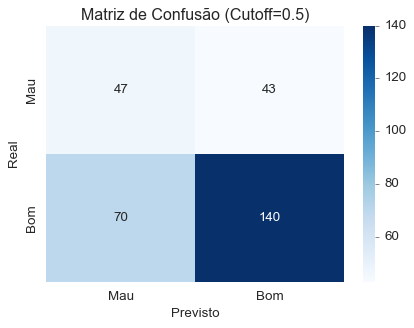


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.40      0.52      0.45        90
           1       0.77      0.67      0.71       210

    accuracy                           0.62       300
   macro avg       0.58      0.59      0.58       300
weighted avg       0.66      0.62      0.63       300



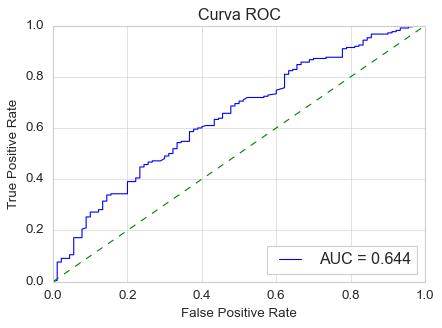

In [668]:
# ==================================================
# AVALIAÇÃO DO MODELO
# ==================================================

# -----------------------------------------
# PREDIÇÕES
# -----------------------------------------
y_pred = modelo_log.predict(X_test)
y_prob = modelo_log.predict_proba(X_test)[:, 1]

# -----------------------------------------
# ACURÁCIA
# -----------------------------------------
from sklearn.metrics import accuracy_score
acuracia = accuracy_score(y_test, y_pred)

print("Acurácia:")
print(acuracia)

# -----------------------------------------
# AUC ROC
# -----------------------------------------
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_prob)

# -----------------------------------------
# GINI
# -----------------------------------------
gini = 2 * auc - 1

print("\nGini:")
print(gini)

print("\nROC AUC:")
print(auc)

# -----------------------------------------
# KS (Kolmogorov-Smirnov)
# -----------------------------------------
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

ks = max(tpr - fpr)

print("\nKS Statistic:")
print(ks)

# -----------------------------------------
# MATRIZ DE CONFUSÃO (HEATMAP)
# -----------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cutoff = 0.5
y_pred_cutoff = (y_prob >= cutoff).astype(int)

cm = confusion_matrix(y_test, y_pred_cutoff)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Mau','Bom'],
    yticklabels=['Mau','Bom']
)

plt.title(f"Matriz de Confusão (Cutoff={cutoff})")
plt.ylabel("Real")
plt.xlabel("Previsto")

plt.show()

# -----------------------------------------
# RELATÓRIO DE CLASSIFICAÇÃO
# -----------------------------------------
from sklearn.metrics import classification_report

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_cutoff))

# -----------------------------------------
# GRÁFICO - CURVA ROC
# -----------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()

### 13º Etapa: Relatório — Modelo Baseline de Risco de Crédito

1. VISÃO GERAL DO MODELO: <BR>

- Tipo de modelo: Regressão Logística <BR>
- Pré-processamento: Weight of Evidence (WOE) <BR>
- Balanceamento: SMOTE aplicado apenas no treino <BR>
- Divisão dos dados: 70% treino / 30% teste (estratificado) <BR>
- Objetivo: Classificação de risco de crédito (bom vs inadimplente) <BR>

2. MÉTRICAS E PERFORMANCE:

- A AUC (0.64) indica baixa capacidade do modelo em diferenciar bons e maus pagadores <BR>
- O Gini (0.28) confirma que o poder preditivo está abaixo do ideal de mercado (~0.40+) <BR>
- O KS (0.21) mostra baixa separação entre as distribuições de bons e inadimplentes <BR>
- A acurácia (0.62) não é confiável, pois pode estar inflada pela maioria de bons clientes <BR>
- O recall dos inadimplentes (0.52) mostra que o modelo deixa passar 48% dos maus pagadores <BR>
- A precision dos inadimplentes (0.40) indica muitos falsos positivos (erros ao classificar bons como maus) <BR>
- O F1 dos inadimplentes (0.45) reforça o baixo equilíbrio na identificação de risco <BR>
- O recall dos bons pagadores (0.67) mostra desempenho melhor na identificação de clientes saudáveis <BR>
- A precision dos bons pagadores (0.77) indica boa confiabilidade ao classificar clientes como bons <BR>
- O F1 dos bons (0.71) confirma um bom equilíbrio para essa classe <BR>
No geral, o modelo apresenta viés para bons pagadores, sendo pouco sensível ao risco de inadimplência <BR>


3. PROBLEMAS IDENTIFICADOS: <BR>

- Estrutura metodológica adequada (WOE + regressão logística + balanceamento)✔️<BR>
- Variáveis com baixo poder preditivo (dados cadastrais não capturam comportamento real — como renda, histórico de atraso, utilização de crédito)<BR>
- Limitação do modelo linear (não capta relações não lineares nem interações entre variáveis) ❌ <BR>
- Redução de variabilidade com WOE (agrupamento em bins simplifica os dados e perde nuances de risco) ❌<BR>


4. FOCO ESTRATÉGICO: <BR>

- Extrair o máximo possível dos dados atuais <BR>
- Melhorar o modelo sem depender de novas variáveis (pois o dataset disponível não possui dados comportamentais e não há novas fontes de dados no momento) <BR>
- Aumentar principalmente o recall de inadimplentes <BR>


5. PLANO DE AÇÃO PARA MELHORIA:

- Ajustar o threshold de decisão <BR>
(Melhorar a detecção de inadimplentes sem alterar os dados, apenas ajustando a regra de decisão do modelo) <BR>

- Substituir SMOTE por class_weight <BR>
(Evitar distorções nos dados sintéticos e melhorar a generalização usando apenas os dados disponíveis) <BR>

- Testar modelo sem WOE <BR>
(Verificar se é possível ganhar performance sem perder informação, utilizando melhor os dados atuais) <BR>

- Avaliar modelos mais robustos <BR>
(Extrair relações mais complexas a partir das mesmas variáveis, sem necessidade de novos dados) <BR>

- Revisar variáveis atuais (feature engineering leve) <BR>
(Criar novas combinações entre variáveis existentes para gerar mais informação sem depender de dados externos) <BR>



### 14º Etapa: de Otimização do Modelo

Utilizamos modelos mais robustos, como Random Forest e XGBoost, para capturar relações não lineares e interações entre variáveis, superando a limitação da Regressão Logística. <br>

Aplicamos feature engineering para criar novas variáveis a partir das existentes, pois não há disponibilidade de dados externos ou comportamentais, buscando extrair o máximo de informação possível da base atual.<br>

Utilizamos one-hot encoding para transformar variáveis categóricas em formato numérico, permitindo o uso adequado nos modelos.<br>

Optamos por class_weight para tratar o desbalanceamento, pois ajusta a importância das classes sem gerar dados artificiais.<br>

Por fim, otimizamos o threshold com base no KS para definir o melhor ponto de decisão, maximizando a separação entre bons e maus pagadores.

In [669]:
# ==================================================
# 1. IMPORTS
# ==================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# ==================================================
# 2. BASE
# ==================================================
df = df_final.copy()
df['Risco'] = df['Risco'].map({'good':1, 'bad':0})

# ==================================================
# 3. FEATURE ENGINEERING
# ==================================================
df['idade_trabalho'] = df['Faixa_Etaria'].astype(str) + "_" + df['Trabalho'].astype(str)
df['credito_habitacao'] = df['Faixa_Credito'].astype(str) + "_" + df['Habitação'].astype(str)
df['conta_status'] = df['Conta_corrente'].astype(str) + "_" + df['Conta_poupança'].astype(str)

# ==================================================
# 4. SPLIT
# ==================================================
X = df.drop('Risco', axis=1)
y = df['Risco']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ==================================================
# 5. ENCODING
# ==================================================
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# ==================================================
# 6. MODELOS
# ==================================================
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)

scale_pos_weight = (y_train == 1).sum() / (y_train == 0).sum()
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Treinar
log_model.fit(X_train_enc, y_train)
rf_model.fit(X_train_enc, y_train)
xgb_model.fit(X_train_enc, y_train)

# Probabilidades
y_prob_log = log_model.predict_proba(X_test_enc)[:,1]
y_prob_rf = rf_model.predict_proba(X_test_enc)[:,1]
y_prob_xgb = xgb_model.predict_proba(X_test_enc)[:,1]

# ==================================================
# 7. FUNÇÃO KS
# ==================================================
def melhor_threshold(y_true, y_prob):
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_ks = 0
    best_t = 0.5

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)

        ks = tpr - fpr

        if ks > best_ks:
            best_ks = ks
            best_t = t

    return best_t, best_ks

# ==================================================
# 8. AVALIAÇÃO
# ==================================================
def avaliar(nome, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    t, ks = melhor_threshold(y_true, y_prob)

    return {"Modelo": nome, "AUC": auc, "Gini": gini, "KS": ks, "Threshold": t}

res = pd.DataFrame([
    avaliar("Logística", y_test, y_prob_log),
    avaliar("Random Forest", y_test, y_prob_rf),
    avaliar("XGBoost", y_test, y_prob_xgb)
])

print("\n📊 Comparação de Modelos:")
print(res)

# ==================================================
# 9. MELHOR MODELO (KS)
# ==================================================
best_model = res.sort_values(by="KS", ascending=False).iloc[0]
print("\n🏆 Melhor modelo:", best_model["Modelo"])

if best_model["Modelo"] == "XGBoost":
    y_prob_final = y_prob_xgb
elif best_model["Modelo"] == "Random Forest":
    y_prob_final = y_prob_rf
else:
    y_prob_final = y_prob_log




📊 Comparação de Modelos:
          Modelo       AUC      Gini        KS  Threshold
0      Logística  0.621667  0.243333  0.184127       0.54
1  Random Forest  0.628915  0.257831  0.230159       0.53
2        XGBoost  0.619339  0.238677  0.233333       0.82

🏆 Melhor modelo: XGBoost


### 15º Etapa: Scoring Crédito



📊 Inadimplência por faixa:
   Faixa  total  inadimplentes  taxa_inadimplencia
0  Baixo    281             83            0.295374
1  Médio     12              5            0.416667
2   Alto      7              2            0.285714


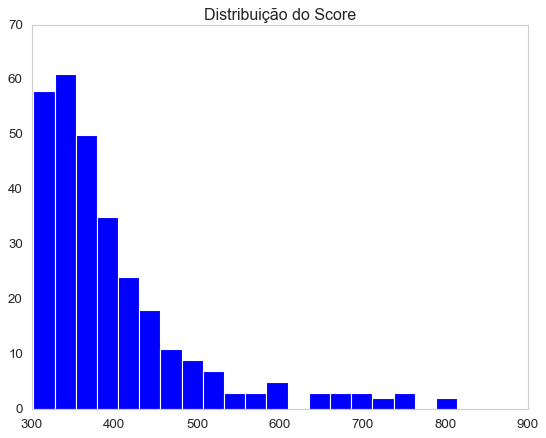

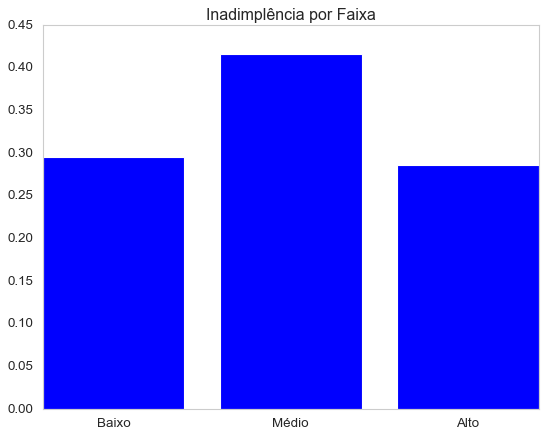


📌 Amostra final:
        Score      Prob  Target  Faixa   Decisao
0  304.987000  0.990933       0  Baixo  Reprovar
1  403.531311  0.811761       1  Baixo  Reprovar
2  420.148926  0.781547       1  Baixo  Reprovar
3  374.749481  0.864092       1  Baixo  Reprovar
4  571.777161  0.505860       1  Baixo  Reprovar


In [670]:
# ==================================================
# 10. SCORE 300–850
# ==================================================
score = 850 - (y_prob_final * 550)

df_score = pd.DataFrame({
    "Score": score,
    "Prob": y_prob_final,
    "Target": y_test.values
})

# ==================================================
# 11. FAIXAS AJUSTADAS (ROBUSTAS)
# ==================================================
df_score["Faixa"] = pd.cut(
    df_score["Score"],
    bins=[300,600,700,850],
    labels=["Baixo","Médio","Alto"]
)

# ==================================================
# 12. VALIDAÇÃO (BAD RATE)
# ==================================================
df_faixa = df_score.groupby("Faixa").agg(
    total=("Target","count"),
    inadimplentes=("Target", lambda x: (x==0).sum()),
    taxa_inadimplencia=("Target", lambda x: 1 - x.mean())
).reset_index()

print("\n📊 Inadimplência por faixa:")
print(df_faixa)

# ==================================================
# 13. POLÍTICA DE CRÉDITO
# ==================================================
def politica(score):
    if score >= 700:
        return "Aprovar"
    elif score >= 600:
        return "Análise Manual"
    else:
        return "Reprovar"

df_score["Decisao"] = df_score["Score"].apply(politica)

# ==================================================
# 14. GRÁFICOS
# ==================================================

# Score distribuição
plt.figure()
plt.hist(df_score["Score"], bins=20)
plt.title("Distribuição do Score")
plt.grid()
plt.show()

# Bad rate
plt.figure()
plt.bar(df_faixa["Faixa"], df_faixa["taxa_inadimplencia"])
plt.title("Inadimplência por Faixa")
plt.grid()
plt.show()

# ==================================================
# 15. OUTPUT FINAL
# ==================================================
print("\n📌 Amostra final:")
print(df_score.head())

### 16º Etapa: Conclusão Final do Projeto

O modelo selecionado foi o XGBoost, por apresentar o melhor desempenho na métrica de KS, principal critério de avaliação em risco de crédito, indicando maior capacidade de separação entre bons e maus pagadores em relação aos demais modelos testados.<br>

A escolha se justifica pela sua capacidade de capturar relações não lineares e interações entre variáveis, além de extrair maior valor das informações disponíveis mesmo em um cenário com limitações de dados.<br>

Ao longo do projeto, foi possível estruturar um pipeline completo de credit scoring, incluindo análise exploratória, seleção de variáveis, modelagem, otimização e, principalmente, a transformação do modelo em um score aplicável com política de decisão de crédito.<br>

Como resultado, o modelo se mostrou capaz de ordenar clientes por nível de risco, permitindo segmentação e apoio à tomada de decisão, reduzindo subjetividade no processo de concessão.<br>

No entanto, a principal limitação do modelo não está na técnica utilizada, mas na ausência de variáveis comportamentais, como histórico de pagamento, renda e utilização de crédito, que são determinantes para capturar o risco real do cliente.<br>

Como consequência, o modelo apresenta uma capacidade de separação moderada, impactando diretamente sua eficácia na identificação de inadimplentes e limitando o potencial de geração de valor financeiro.<br>

Como próximos passos, recomenda-se o enriquecimento da base com variáveis comportamentais, além da evolução contínua do modelo com monitoramento de performance, recalibração do score e testes com novas abordagens.<br>

- Em síntese, o projeto demonstra que é possível construir um sistema de credit scoring funcional e aplicável, mas reforça que a qualidade e profundidade dos dados são fatores decisivos para atingir níveis mais altos de performance e impacto no negócio.

In [671]:
# Verificar de qual pasta ou local estamos executando...
import os
print(os.getcwd())


# ==================================================
# 🚀 SALVAR TODOS OS ARTEFATOS DO PROJETO
# ==================================================

import os
import pandas as pd
import joblib
import json
from sklearn.metrics import confusion_matrix

# ==================================================
# 📁 BASE PATH (SUA PASTA DO PROJETO)
# ==================================================
BASE_PATH = "Projeto_Risco_Credito"

# criar estrutura
os.makedirs(f"{BASE_PATH}/data/processed", exist_ok=True)
os.makedirs(f"{BASE_PATH}/models", exist_ok=True)
os.makedirs(f"{BASE_PATH}/outputs", exist_ok=True)

# ==================================================
# 📊 1. SALVAR DATASET TRATADO
# ==================================================
df.to_csv(f"{BASE_PATH}/data/processed/dataset_features.csv", index=False)

# ==================================================
# 🤖 2. SALVAR MODELO
# ==================================================
joblib.dump(model_final, f"{BASE_PATH}/models/modelo_final.pkl")

# ==================================================
# 💰 3. SALVAR RESULTADO (LUCRO + THRESHOLD)
# ==================================================
resultado = pd.DataFrame({
    "lucro": [melhor_lucro],
    "threshold": [melhor_t]
})

resultado.to_csv(f"{BASE_PATH}/outputs/resultado_modelo.csv", index=False)

# ==================================================
# 📊 4. MATRIZ DE CONFUSÃO
# ==================================================
tn, fp, fn, tp = confusion_matrix(y, y_pred_final).ravel()

matriz = pd.DataFrame({
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

matriz.to_csv(f"{BASE_PATH}/outputs/matriz_confusao.csv", index=False)

# ==================================================
# 🧠 5. FEATURES USADAS
# ==================================================
features = X.columns

pd.DataFrame(features, columns=["features"]).to_csv(
    f"{BASE_PATH}/outputs/features_usadas.csv",
    index=False
)

# ==================================================
# ⚙️ 6. PARÂMETROS DO MODELO (OPTUNA)
# ==================================================
with open(f"{BASE_PATH}/outputs/melhores_parametros.json", "w") as f:
    json.dump(study.best_params, f)

# ==================================================
# 📈 7. PREDIÇÕES
# ==================================================
df_resultado = df.copy()

# garantir que variáveis existem
df_resultado["score"] = y_prob_oof
df_resultado["predicao"] = y_pred_final

df_resultado.to_csv(f"{BASE_PATH}/outputs/predicoes.csv", index=False)

# ==================================================
# ✅ FINAL
# ==================================================
print("\n🚀 TUDO SALVO COM SUCESSO!")
print(f"📁 Pasta base: {BASE_PATH}")

c:\Users\Fernanda Pavan\OneDrive\Desktop\Projeto_Fer

🚀 TUDO SALVO COM SUCESSO!
📁 Pasta base: Projeto_Risco_Credito
